# Loan Approval Classification Using Machine Learning

## An end-to-end machine learning project for predicting loan approval status.

---

## Description

This project explores the use of machine learning to predict loan approval status based on applicants' financial and personal characteristics.

Three classification models are developed and compared: Logistic Regression, Random Forest, and Support Vector Machine (SVM). The workflow covers exploratory data analysis, data preprocessing, feature selection, model evaluation, and model improvement.

Several techniques are applied to improve and analyze model performance, including cross-validation, hyperparameter tuning, SMOTE, class weighting, and threshold tuning. Model performance is evaluated using accuracy, precision, recall, F1-score, confusion matrix, ROC-AUC, and other classification metrics.

The project also examines feature importance and discusses how the model can support the initial screening of loan applications.

## 2. Dataset

The dataset contains 45,000 records and 14 columns. It includes applicant demographic, financial, employment, credit, and loan-related information.

The target variable is `loan_status`, while the remaining variables are used as input features for the classification models.

### Main Features

- `person_age` — Applicant's age
- `person_gender` — Applicant's gender
- `person_education` — Applicant's education level
- `person_income` — Applicant's annual income
- `person_emp_exp` — Years of employment experience
- `person_home_ownership` — Home ownership status
- `loan_amnt` — Loan amount
- `loan_intent` — Purpose of the loan
- `loan_int_rate` — Loan interest rate
- `loan_percent_income` — Loan amount as a percentage of income
- `cb_person_cred_hist_length` — Length of credit history
- `credit_score` — Applicant's credit score
- `previous_loan_defaults_on_file` — Previous loan default history
- `loan_status` — Target variable indicating loan approval status

# 1. Import Library

In [129]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

plt.style.use('ggplot')

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


# 2. Load Dataset

## 2.1 Membaca Dataset

Dataset dibaca menggunakan library **Pandas**. File dataset berada pada folder `data` dengan nama `loan_data.csv`.

In [130]:
df = pd.read_csv("data/loan_data.csv")


## 2.2 Menampilkan 5 Data Pertama

Lima data pertama ditampilkan untuk memastikan dataset berhasil dimuat serta memberikan gambaran awal mengenai struktur data.

In [131]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


## 2.3 Informasi Awal Dataset

Pada tahap ini dilakukan pengecekan informasi awal dataset untuk mengetahui ukuran dataset serta atribut yang tersedia. Informasi ini akan membantu dalam proses analisis dan pemodelan Machine Learning.

In [132]:
print("Dimensi Dataset :", df.shape)

print("\nNama Kolom:")
print(df.columns.tolist())

Dimensi Dataset : (45000, 14)

Nama Kolom:
['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file', 'loan_status']


### Interpretasi

Berdasarkan hasil pengecekan, datasetnya udah memiliki **45.000 baris** dan **14 kolom**. Kolom `loan_status` akan digunakan sebagai **variabel target**, sedangkan kolom lainnya digunakan sebagai **fitur (variabel independen)** dalam proses pemodelan.

## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik dataset sebelum masuk ke tahap preprocessing dan model development.

Analisis meliputi:
- Dataset structure
- Descriptive statistics
- Missing values
- Duplicate data
- Target distribution
- Numerical feature distributions
- Categorical feature distributions
- Feature correlation

## 3.1 Struktur Dataset

Tahap ini bertujuan untuk mengetahui struktur dataset, tipe data setiap atribut, jumlah data yang tidak kosong, dan penggunaan memori.

In [133]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

### Interpretasi

Dataset terdiri dari 45.000 baris dan 14 kolom. Data memiliki kombinasi fitur numerik dan kategorikal yang nantinya perlu diproses sebelum digunakan dalam model.

## 3.2 Statistik Deskriptif

Statistik deskriptif digunakan untuk melihat ringkasan data numerik, seperti nilai rata-rata, nilai minimum, nilai maksimum, dan persebaran data.

In [134]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


### Interpretasi

Dari statistik deskriptif terlihat adanya beberapa nilai yang cukup ekstrem, terutama pada `person_age`, `person_emp_exp`, dan `person_income`. Nilai tersebut kemudian menjadi perhatian pada tahap preprocessing, khususnya dalam proses outlier handling.

## 3.3 Pengecekan Missing Value

Pengecekan missing value dilakukan untuk mengetahui apakah terdapat data yang kosong pada setiap atribut sehingga dapat ditentukan apakah diperlukan proses penanganan data hilang.

In [135]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

### Interpretasi

Tidak ditemukan missing value pada dataset. Jadi, tidak diperlukan proses imputasi atau penghapusan data karena nilai pada seluruh kolom sudah terisi.

## 3.4 Pengecekan Data Duplikat

Pengecekan data duplikat dilakukan untuk mengetahui apakah terdapat baris data yang memiliki informasi yang sama sehingga dapat memengaruhi hasil analisis dan pemodelan.

In [136]:
print("Jumlah data duplikat:", df.duplicated().sum())

Jumlah data duplikat: 0


### Interpretasi

Tidak ditemukan data duplikat pada dataset, sehingga seluruh data dapat dilanjutkan ke tahap preprocessing berikutnya.

## 3.5 Distribusi Variabel Target

Tahap ini bertujuan untuk melihat distribusi kelas pada variabel target (`loan_status`). Ini digunakan untuk mengetahui apakah dataset memiliki distribusi kelas yang seimbang atau tidak.

In [137]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

### Visualisasi Distribusi Target

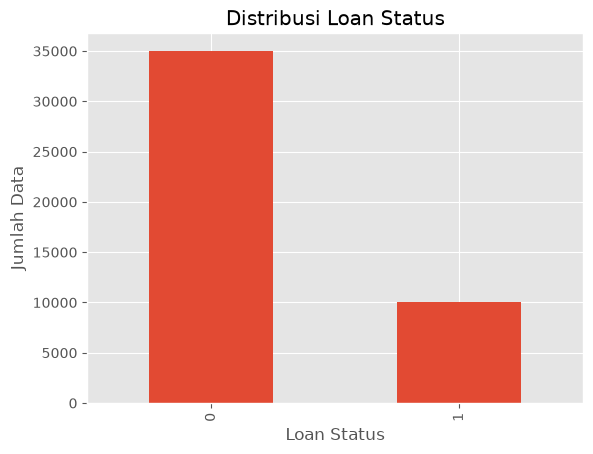

In [138]:
import matplotlib.pyplot as plt

df['loan_status'].value_counts().plot(kind='bar')

plt.title('Distribusi Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Jumlah Data')

plt.show()

### Interpretasi

Berdasarkan hasil visualisasi, jumlah data pada setiap kelas masih imbalanced. Kelas **0** memiliki jumlah data lebih banyak dibandingkan kelas **1**. Kondisi ini menunjukkan adanya **class imbalance** ini perlu diperhatikan karena dapat memengaruhi performa model.

## 3.6 Analisis Outlier

Analisis outlier dilakukan untuk mengidentifikasi nilai yang terlalu extreme. Outlier dapat memengaruhi proses pelatihan model jadi perlu diketahui sebelum dilakukan tahap preprocessing.

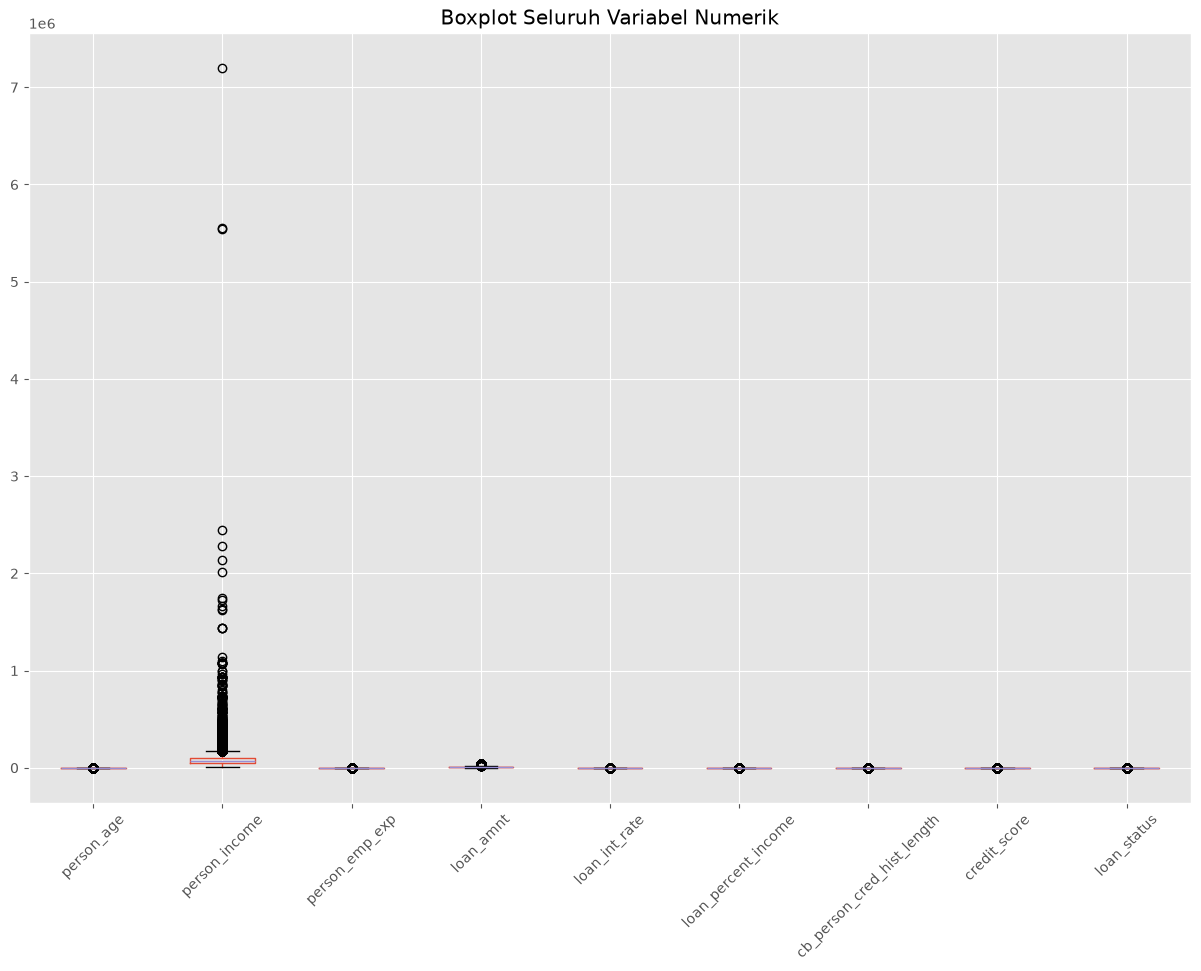

In [139]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15,10))

df[numerical_columns].boxplot(rot=45)

plt.title("Boxplot Seluruh Variabel Numerik")
plt.show()

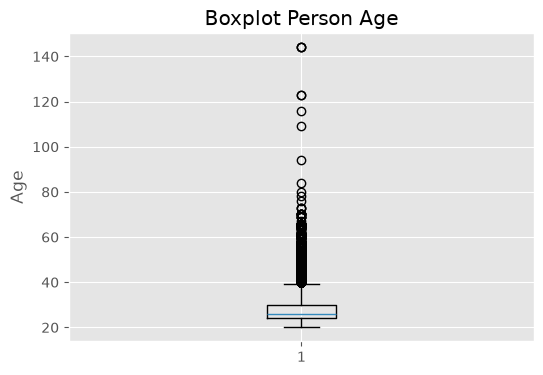

In [140]:
plt.figure(figsize=(6,4))

plt.boxplot(df['person_age'])

plt.title('Boxplot Person Age')

plt.ylabel('Age')

plt.show()

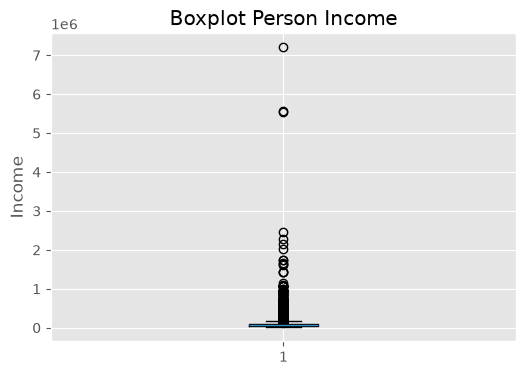

In [141]:
plt.figure(figsize=(6,4))

plt.boxplot(df['person_income'])

plt.title('Boxplot Person Income')

plt.ylabel('Income')

plt.show()

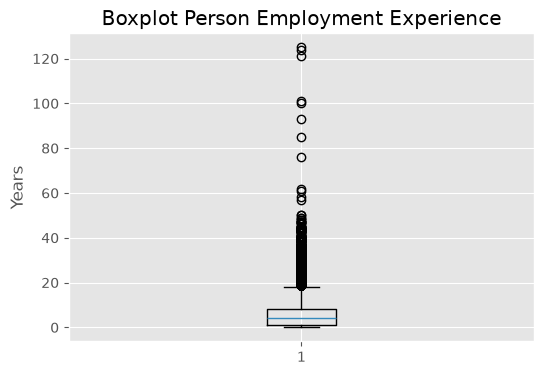

In [142]:
plt.figure(figsize=(6,4))

plt.boxplot(df['person_emp_exp'])

plt.title('Boxplot Person Employment Experience')

plt.ylabel('Years')

plt.show()

### Interpretasi

Berdasarkan hasil boxplot, terdapat beberapa variabel yang memiliki outlier, terutama **person_income**. variabel **person_age** dan **person_emp_exp** juga menunjukkan adanya nilai yang berada di luar rentang data utama. Outlier tersebut akan menjadi perhatian pada tahap preprocessing karena dapat memengaruhi performa model.

## 3.7 Distribusi Variabel Numerik

Visualisasi distribusi variabel numerik dilakukan untuk melihat pola persebaran data pada setiap atribut numerik. Dari visualisasi ini dapat diketahui apakah data memiliki distribusi normal, miring, ataupun adanya nilai ekstrem.

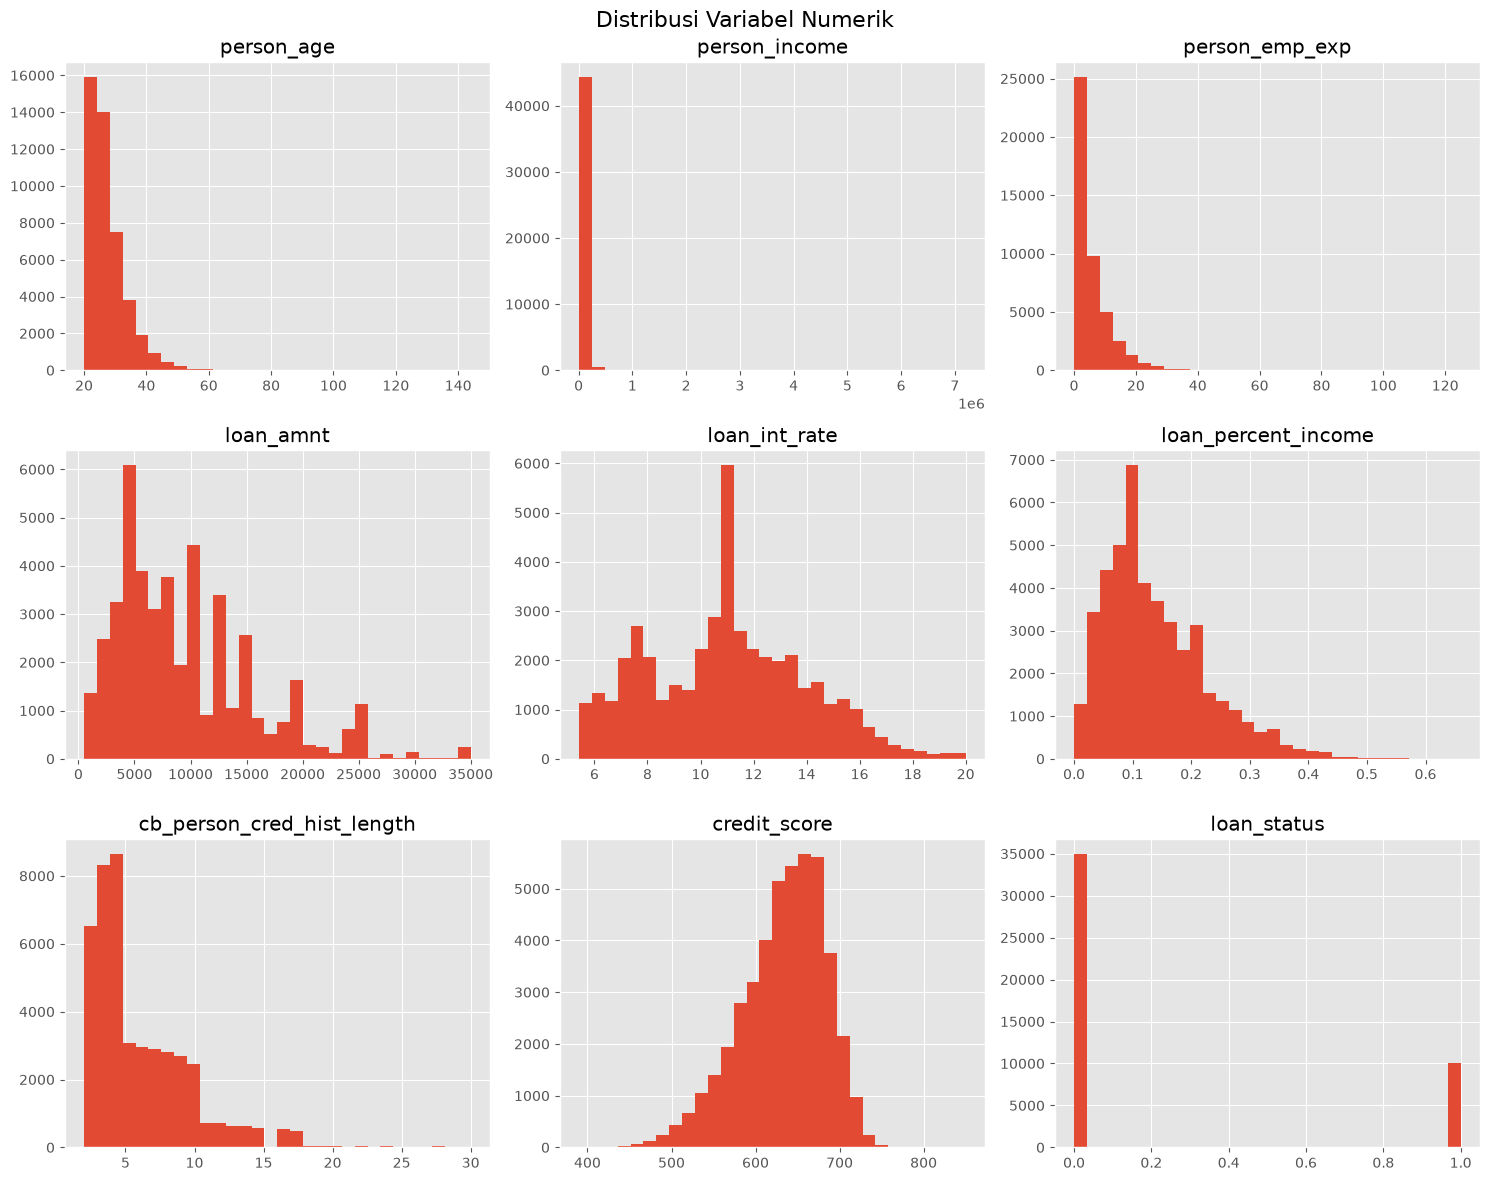

In [143]:
df.hist(figsize=(15,12), bins=30)

plt.suptitle("Distribusi Variabel Numerik", fontsize=16)

plt.tight_layout()

plt.show()

### Interpretasi

Berdasarkan histogram seluruh variabel numerik, sebagian besar fitur memiliki distribusi yang tidak normal dan cenderung **right-skewed**, terutama pada variabel **person_income**, **person_age**, dan **person_emp_exp**. Hal ini menunjukkan adanya beberapa nilai ekstrem pada dataset.



## 3.8 Distribusi Variabel Kategorikal

Visualisasi variabel kategorikal dilakukan untuk mengetahui jumlah data pada setiap kategori sehingga dapat memberikan gambaran mengenai karakteristik dataset.

C:\Users\TEGAR\AppData\Local\Temp\ipykernel_29428\2552603428.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


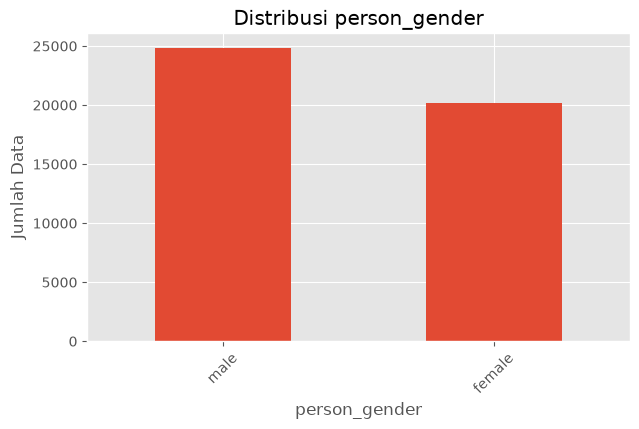

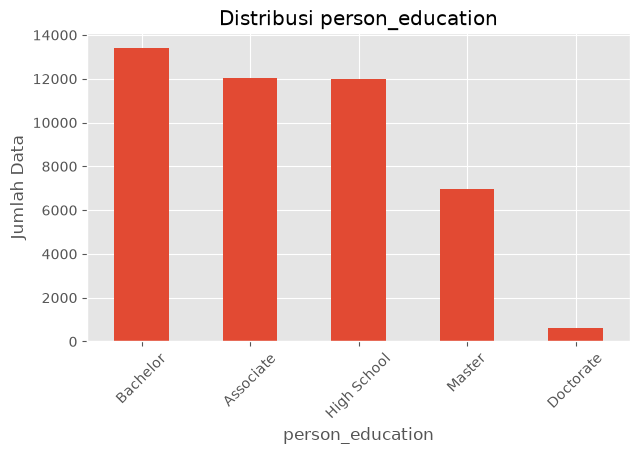

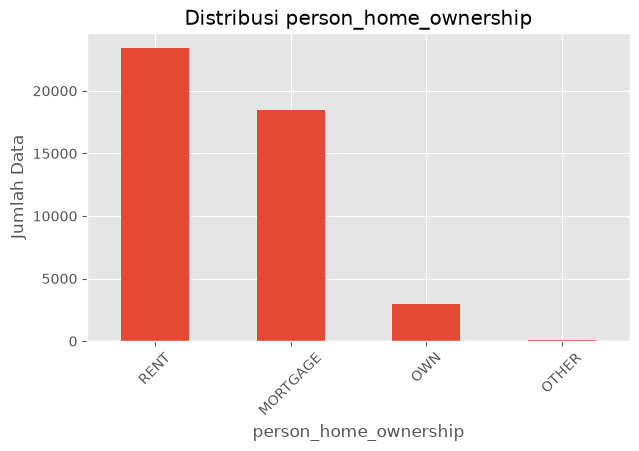

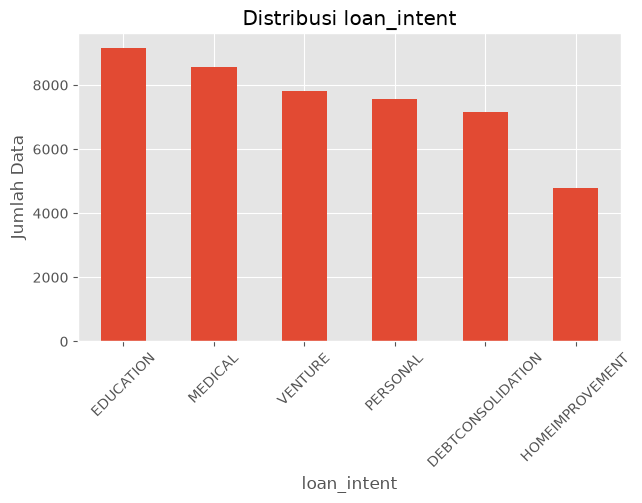

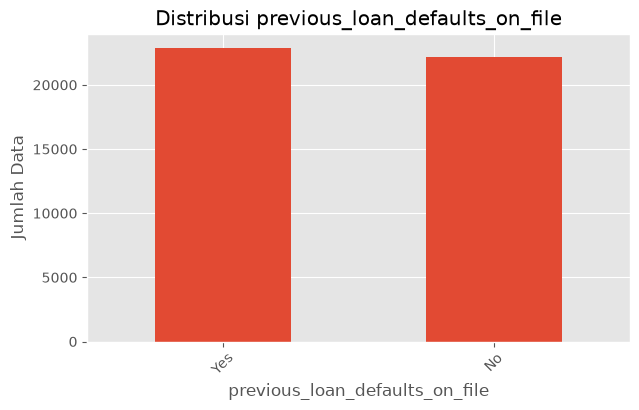

In [144]:
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    plt.figure(figsize=(7,4))

    df[col].value_counts().plot(kind='bar')

    plt.title(f'Distribusi {col}')

    plt.xlabel(col)
    plt.ylabel('Jumlah Data')

    plt.xticks(rotation=45)

    plt.show()

### Interpretasi

Berdasarkan visualisasi variabel kategorikal, dapat dilihat bahwa setiap atribut memiliki jumlah data yang berbeda pada masing-masing kategori.

- Variabel **person_gender** terdiri dari dua kategori, yaitu *male* dan *female*, dengan jumlah yang relatif seimbang.
- Variabel **person_home_ownership** didominasi oleh kategori **RENT**, sedangkan kategori **OTHER** memiliki jumlah data paling sedikit.
- Variabel **loan_intent** menunjukkan bahwa tujuan peminjaman paling banyak digunakan untuk **EDUCATION** dan **MEDICAL**.
- Variabel **person_education** memiliki beberapa tingkat pendidikan dengan distribusi yang cukup beragam.
- Variabel **previous_loan_defaults_on_file** didominasi oleh kategori **No**, yang menunjukkan sebagian besar peminjam tidak memiliki riwayat gagal bayar sebelumnya.

Informasi ini membantu memahami karakteristik data sebelum dilakukan proses preprocessing dan pembangunan model.

## 3.9 Korelasi Antar Variabel Numerik

Heatmap digunakan untuk melihat hubungan antar variabel numerik. Nilai korelasi berada pada rentang -1 hingga 1, dimana nilai yang mendekati 1 menunjukkan hubungan positif yang kuat, sedangkan nilai yang mendekati -1 menunjukkan hubungan negatif yang kuat.

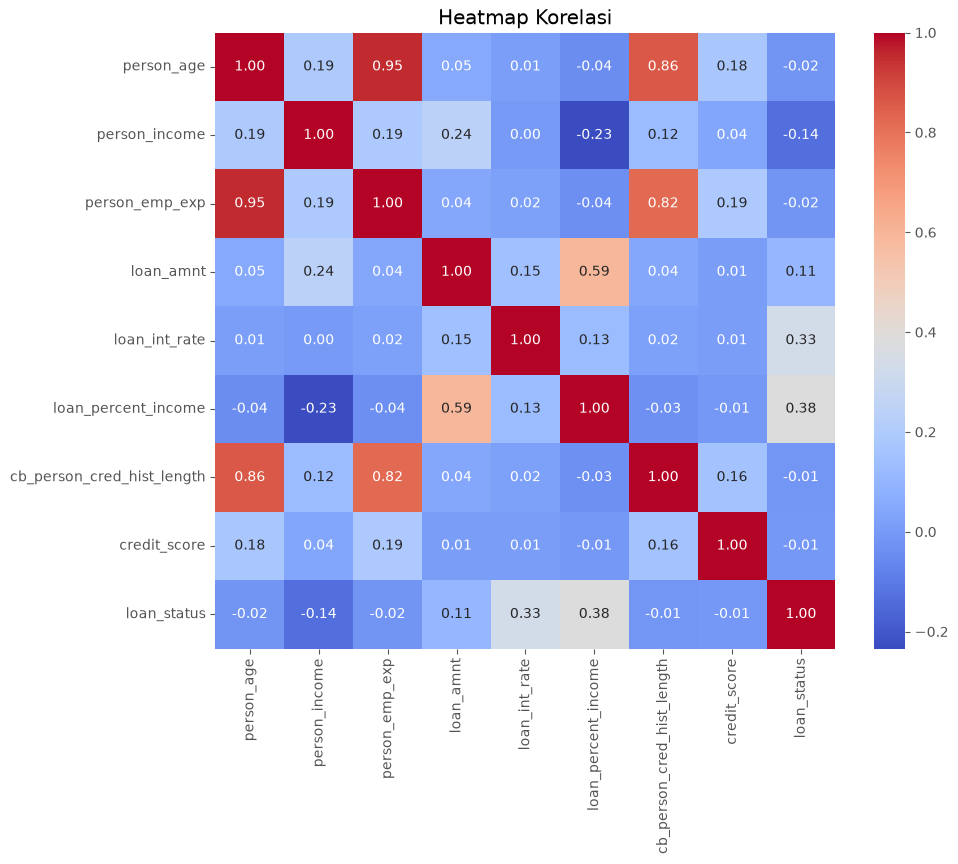

In [145]:
plt.figure(figsize=(10,8))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Heatmap Korelasi")

plt.show()

### Interpretasi

Sebagian besar fitur memiliki hubungan yang rendah hingga sedang dengan `loan_status`. Korelasi yang relatif lebih tinggi terlihat pada `loan_percent_income` dan `loan_int_rate`.

Selain itu, terdapat korelasi yang cukup tinggi antara beberapa fitur seperti `person_age` dan `person_emp_exp`. Temuan ini menjadi pertimbangan pada tahap preprocessing dan feature selection.

## 4. Data Preprocessing

Data preprocessing dilakukan untuk menyiapkan dataset sebelum digunakan dalam proses machine learning. Tahapan yang dilakukan meliputi pengecekan missing value dan data duplikat, penanganan outlier, encoding data kategorikal, pemisahan feature dan target, feature selection, train-test split, serta standardisasi data.

## 4.1 Missing Value Handling

Tahap pertama preprocessing adalah memastikan apakah dataset memiliki nilai yang hilang.

In [146]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

### Interpretasi

Hasil pengecekan menunjukkan bahwa seluruh variabel memiliki nilai missing sebesar **0**, jadi tidak perlu proses penghapusan data.

## 4.2 Duplicate Removal

Selanjutnya lakukan pengecekan apakah terdapat data yang duplikat pada dataset.

In [147]:
print("Jumlah data duplikat :", df.duplicated().sum())

Jumlah data duplikat : 0


### Interpretasi

Tidak ditemukan data duplikat pada dataset, sehingga seluruh data dapat dilanjutkan ke tahap preprocessing berikutnya.

## 4.3 Outlier Handling

Beberapa fitur numerik memiliki nilai ekstrem yang cukup jauh dari sebagian besar data. Oleh karena itu, dilakukan outlier handling menggunakan metode Interquartile Range (IQR).

In [148]:
df_clean = df.copy()

In [149]:
numeric_columns = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'loan_amnt',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length',
    'credit_score'
]

In [150]:
for col in numeric_columns:

    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_clean = df_clean[
        (df_clean[col] >= lower) &
        (df_clean[col] <= upper)
    ]

In [151]:
print("Jumlah data sebelum :", len(df))
print("Jumlah data sesudah :", len(df_clean))

Jumlah data sebelum : 45000
Jumlah data sesudah : 36065


### Interpretasi

Setelah dilakukan outlier handling menggunakan metode IQR, jumlah data berkurang dari 45.000 menjadi 36.065 data. Data yang tersisa kemudian digunakan untuk tahap preprocessing berikutnya.

### Visualisasi Setelah Outlier Handling

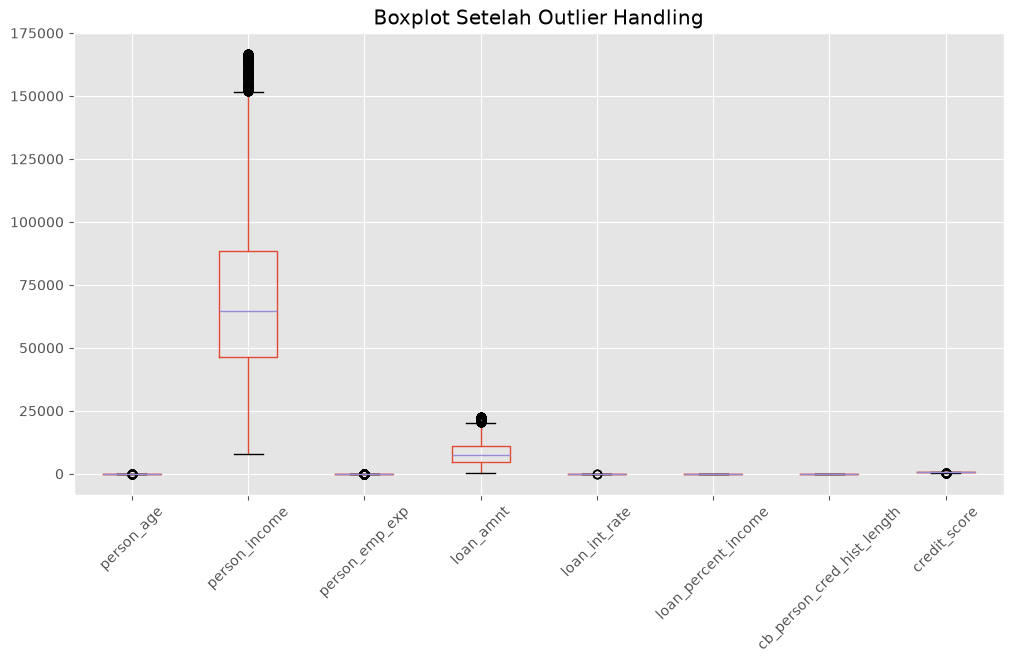

In [152]:
plt.figure(figsize=(12,6))

df_clean[numeric_columns].boxplot(rot=45)

plt.title("Boxplot Setelah Outlier Handling")

plt.show()

### Interpretasi

Setelah dilakukan penanganan outlier menggunakan metode IQR, sebagian besar nilai ekstrem telah berhasil dihilangkan. Distribusi data menjadi lebih representatif sehingga diharapkan dapat meningkatkan kualitas proses pelatihan model Machine Learning.

## 4.4 Categorical Encoding

Sebelum membangun model Machine Learning, seluruh variabel kategorikal perlu diubah menjadi bentuk numerik agar dapat diproses oleh algoritma Machine Learning.

In [153]:
df_clean.select_dtypes(include='string').columns

Index(['person_gender', 'person_education', 'person_home_ownership',
       'loan_intent', 'previous_loan_defaults_on_file'],
      dtype='str')

### Encoding Data Kategorikal

Proses encoding dilakukan untuk mengubah variabel kategorikal menjadi bentuk numerik agar dapat diproses oleh algoritma Machine Learning. Pada penelitian ini digunakan **One-Hot Encoding** karena sebagian besar variabel kategorikal bersifat nominal dan tidak memiliki urutan tertentu.

In [154]:
df_encoded = pd.get_dummies(df_clean, drop_first=True)

df_encoded.head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,person_gender_male,person_education_Bachelor,person_education_Doctorate,person_education_High School,person_education_Master,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,previous_loan_defaults_on_file_Yes
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,False,False,False,True,False,False,True,False,True,False,False,False,False,True
5,21.0,12951.0,0,2500.0,7.14,0.19,2.0,532,1,False,False,False,True,False,False,True,False,False,False,False,False,True,False
9,21.0,12739.0,0,1600.0,14.74,0.13,3.0,640,1,False,False,False,True,False,False,True,False,False,False,False,False,True,False
19,24.0,14283.0,1,1750.0,10.99,0.12,2.0,679,1,False,False,False,False,True,False,False,False,True,False,False,False,False,False
23,24.0,13866.0,0,1500.0,7.29,0.11,3.0,600,0,False,True,False,False,False,False,True,False,False,False,False,True,False,True


In [155]:
df_encoded.shape

(36065, 23)

### Interpretasi

One-Hot Encoding digunakan untuk mengubah data kategorikal menjadi bentuk numerik. Setelah encoding, jumlah kolom bertambah dari 14 menjadi 23 karena setiap kategori diubah menjadi variabel dummy.

## 4.5 Feature and Target

Pada tahap ini dataset dipisahkan menjadi variabel **feature (X)** dan **target (y)**. Variabel target yang digunakan adalah **loan_status**, sedangkan seluruh atribut lainnya digunakan sebagai feature untuk membangun model klasifikasi.

In [156]:
X = df_encoded.drop('loan_status', axis=1)

y = df_encoded['loan_status']

In [157]:
print("Shape Feature (X):", X.shape)
print("Shape Target (y):", y.shape)

Shape Feature (X): (36065, 22)
Shape Target (y): (36065,)


### Interpretasi

Dataset kemudian dipisahkan menjadi feature (X) dan target (y). Variabel `loan_status` digunakan sebagai target, sedangkan 22 variabel lainnya digunakan sebagai feature untuk proses klasifikasi.

## 4.6 Feature Selection

Feature selection dilakukan untuk memilih fitur yang paling relevan terhadap variabel target. Tahap ini bertujuan untuk mengurangi fitur yang kurang berpengaruh sehingga model dapat bekerja lebih optimal dan mengurangi kompleksitas model.

Pada penelitian ini digunakan metode SelectKBest dengan fungsi skor Chi-Square (chi2) untuk menentukan fitur terbaik berdasarkan hubungan antara fitur dengan target `loan_status`.

In [158]:
from sklearn.feature_selection import SelectKBest, chi2

In [159]:
selector = SelectKBest(score_func=chi2, k=10)

X_selected = selector.fit_transform(X, y)

In [160]:
print("Shape sebelum Feature Selection :", X.shape)
print("Shape setelah Feature Selection :", X_selected.shape)

Shape sebelum Feature Selection : (36065, 22)
Shape setelah Feature Selection : (36065, 10)


In [161]:
selected_features = X.columns[selector.get_support()]

print("Fitur yang dipilih:")
for feature in selected_features:
    print(feature)

Fitur yang dipilih:
person_income
loan_amnt
loan_int_rate
loan_percent_income
person_home_ownership_OWN
person_home_ownership_RENT
loan_intent_EDUCATION
loan_intent_MEDICAL
loan_intent_VENTURE
previous_loan_defaults_on_file_Yes


### Interpretasi

Dari 22 feature awal, SelectKBest dengan Chi-Square memilih 10 feature yang paling relevan terhadap `loan_status`. Pengurangan feature ini membuat model bekerja dengan jumlah variabel yang lebih sedikit tanpa menghilangkan feature yang dianggap paling relevan untuk proses klasifikasi.

## 4.7 Train-Test Split

Dataset dibagi menjadi data training dan data testing dengan proporsi 80:20. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengevaluasi kemampuan model terhadap data baru yang belum pernah dipelajari sebelumnya.

In [162]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [163]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (28852, 10)
X_test  : (7213, 10)
y_train : (28852,)
y_test  : (7213,)


### Interpretasi

Dataset dibagi menjadi data training dan testing dengan proporsi 80:20. Data training terdiri dari 28.852 data, sedangkan data testing terdiri dari 7.213 data. Kedua bagian tersebut menggunakan 10 feature hasil dari tahap feature selection.

## 4.8 Standardization

Standardisasi dilakukan untuk menyamakan skala setiap fitur numerik sehingga tidak ada fitur yang mendominasi fitur lainnya. Tahap ini diperlukan terutama untuk algoritma yang sensitif terhadap skala data seperti Logistic Regression dan SVM.

In [164]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [165]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(28852, 10)
(7213, 10)


### Interpretasi

Standardisasi dilakukan menggunakan `StandardScaler` untuk menyamakan skala feature. Tahap ini terutama penting untuk algoritma seperti Logistic Regression dan SVM yang sensitif terhadap perbedaan skala antar feature.

## 5. Model Development

Tiga algoritma klasifikasi dikembangkan dan dibandingkan untuk memprediksi status persetujuan pinjaman:

1. Regresi Logistik
2. Random Forest
3. Support Vector Machine (SVM)

Setiap model dilatih menggunakan data pelatihan yang telah diproses dan distandarisasi, kemudian dievaluasi menggunakan data pengujian.

## 5.1 Logistic Regression

Logistic Regression merupakan algoritma klasifikasi yang digunakan untuk memprediksi probabilitas suatu kelas. Algoritma ini cocok digunakan untuk permasalahan klasifikasi biner seperti prediksi persetujuan pinjaman.

In [166]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

### Parameter Model

Model Logistic Regression dibangun menggunakan parameter `random_state=42`. Parameter ini digunakan agar proses pelatihan model menghasilkan output yang konsisten setiap kali program dijalankan, sehingga memudahkan proses evaluasi dan reproduksi hasil.

In [167]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [168]:
y_pred_lr = lr.predict(X_test_scaled)

y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [169]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Accuracy :", accuracy_lr)

Accuracy : 0.8903368917232775


### Interpretasi

Logistic Regression memperoleh accuracy sebesar 89,03%. Model ini dapat digunakan sebagai baseline untuk melihat seberapa jauh performa model lain setelah menggunakan algoritma yang lebih kompleks.

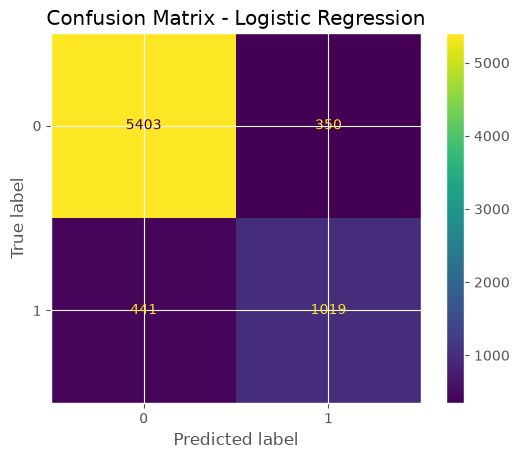

In [170]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr)

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

### Interpretasi

Model berhasil mengidentifikasi 5.403 data pinjaman yang memang tidak disetujui dengan benar serta 1.019 data pinjaman yang disetujui dengan benar. Masih terdapat 350 data yang diprediksi disetujui padahal sebenarnya tidak, dan 441 data yang diprediksi tidak disetujui padahal sebenarnya disetujui.

In [171]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

TN, FP, FN, TP = cm.ravel()

specificity = TN / (TN + FP)
error_rate = (FP + FN) / (TP + TN + FP + FN)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

print("Specificity :", specificity)
print("Error Rate  :", error_rate)
print("False Positive Rate :", fpr)
print("False Negative Rate :", fnr)

Specificity : 0.9391621762558665
Error Rate  : 0.10966310827672258
False Positive Rate : 0.0608378237441335
False Negative Rate : 0.30205479452054795


### Interpretasi

Model Logistic Regression memperoleh accuracy sebesar 89,03%. Nilai specificity sebesar 93,92% menunjukkan bahwa model mampu mengenali dengan baik data pada kelas negatif (kelas 0). 

Nilai False Positive Rate (FPR) sebesar 6,08% menunjukkan proporsi data negatif yang salah diklasifikasikan sebagai positif, sedangkan False Negative Rate (FNR) sebesar 30,21% menunjukkan proporsi data positif yang masih salah diprediksi sebagai negatif.

Hasil evaluasi menunjukkan bahwa Logistic Regression memiliki kemampuan klasifikasi yang cukup baik setelah dilakukan proses feature selection, dengan tingkat kesalahan prediksi sebesar 10,97%.

In [172]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      5753
           1       0.74      0.70      0.72      1460

    accuracy                           0.89      7213
   macro avg       0.83      0.82      0.83      7213
weighted avg       0.89      0.89      0.89      7213



### Interpretasi

1. Precision kelas positif (kelas 1) sebesar 74%, artinya dari seluruh data yang diprediksi sebagai kelas positif, sekitar 74% prediksi tersebut benar.

2. Recall kelas positif sebesar 70%, menunjukkan bahwa model mampu mengenali sekitar 70% dari seluruh data yang sebenarnya termasuk kelas positif.

3. F1-Score kelas positif sebesar 72%, menunjukkan keseimbangan antara kemampuan model dalam menghasilkan prediksi positif yang tepat (precision) dan kemampuan menemukan seluruh data positif (recall).

4. Model memiliki accuracy sebesar 89%, yang menunjukkan bahwa sebagian besar data pengujian berhasil diklasifikasikan dengan benar.

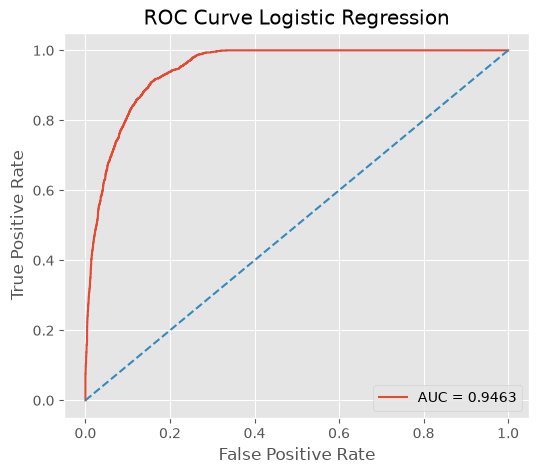

In [173]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(6,5))

plt.plot(fpr_lr, tpr_lr, label=f"AUC = {auc_lr:.4f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Logistic Regression")

plt.legend()

plt.show()

In [174]:
print("AUC Score :", auc_lr)

AUC Score : 0.9463466351087819


Interpretasi

Nilai AUC sebesar 0,9463 menunjukkan kemampuan model dalam membedakan antara pinjaman yang disetujui dan tidak disetujui berada pada kategori sangat baik (Excellent Classification). Semakin mendekati nilai 1, semakin baik kemampuan model dalam melakukan klasifikasi.

### Precision-Recall Curve

Precision-Recall Curve digunakan untuk mengevaluasi performa model klasifikasi, terutama pada dataset yang memiliki distribusi kelas tidak seimbang. Kurva ini menunjukkan hubungan antara nilai precision dan recall pada berbagai nilai threshold.

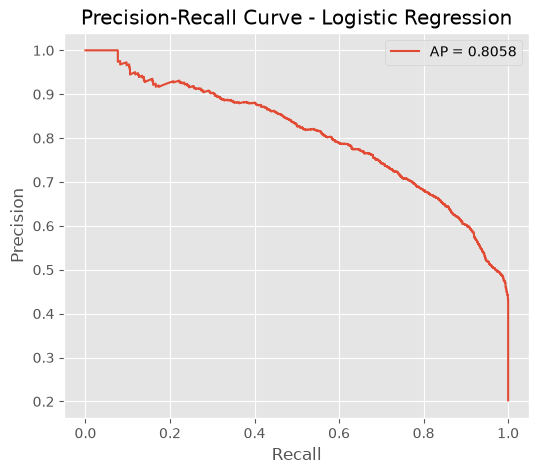

Average Precision : 0.8058094317258134


In [175]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lr)

ap_score = average_precision_score(y_test, y_prob_lr)

plt.figure(figsize=(6,5))

plt.plot(recall, precision, label=f"AP = {ap_score:.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")

plt.legend()

plt.show()

print("Average Precision :", ap_score)

### Interpretasi

Berdasarkan hasil Precision-Recall Curve, diperoleh nilai **Average Precision (AP) sebesar 0,8058**. Nilai tersebut menunjukkan bahwa model memiliki kemampuan yang baik dalam mempertahankan keseimbangan antara **precision** dan **recall** pada berbagai nilai threshold. Hal ini menunjukkan bahwa Logistic Regression cukup efektif dalam mengidentifikasi kelas positif meskipun dataset memiliki distribusi kelas yang tidak seimbang.

### Learning Curve

Learning Curve digunakan untuk mengevaluasi performa model seiring bertambahnya jumlah data latih. Grafik ini membantu mengetahui apakah model mengalami overfitting, underfitting, atau telah memiliki kemampuan generalisasi yang baik.

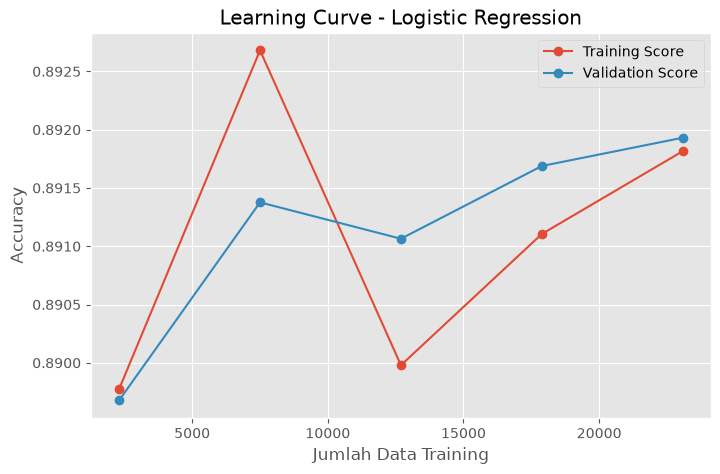

In [176]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
plt.plot(train_sizes, test_mean, marker='o', label='Validation Score')

plt.title("Learning Curve - Logistic Regression")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Accuracy")
plt.legend()

plt.grid(True)

plt.show()

### Interpretasi

Berdasarkan Learning Curve, nilai akurasi pada data training dan validation cenderung stabil serta memiliki selisih yang kecil. Seiring bertambahnya jumlah data training, performa model pada data validation tetap berada pada rentang yang stabil dan mendekati performa data training.

Hal ini menunjukkan bahwa model Logistic Regression memiliki kemampuan generalisasi yang baik. Tidak terdapat perbedaan performa yang besar antara data training dan validation, sehingga model tidak menunjukkan indikasi overfitting maupun underfitting yang signifikan.

### Analisis Koefisien

Koefisien pada Logistic Regression digunakan untuk melihat pengaruh setiap variabel terhadap hasil prediksi. Semakin besar nilai absolut koefisien, maka semakin besar pengaruh variabel tersebut terhadap keputusan model.

In [177]:
coef = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": lr.coef_[0]
})

coef["Absolute"] = coef["Coefficient"].abs()

coef = coef.sort_values(
    by="Absolute",
    ascending=False
)

coef.head(10)

,Feature,Coefficient,Absolute
9,previous_loan_defaults_on_file_Yes,-4.250143,4.250143
3,loan_percent_income,1.259539,1.259539
2,loan_int_rate,0.952951,0.952951
1,loan_amnt,-0.734250,0.734250
4,person_home_ownership_OWN,-0.391425,0.391425
8,loan_intent_VENTURE,-0.382969,0.382969
6,loan_intent_EDUCATION,-0.284501,0.284501
5,person_home_ownership_RENT,0.239442,0.239442
0,person_income,-0.034184,0.034184
7,loan_intent_MEDICAL,-0.019930,0.019930


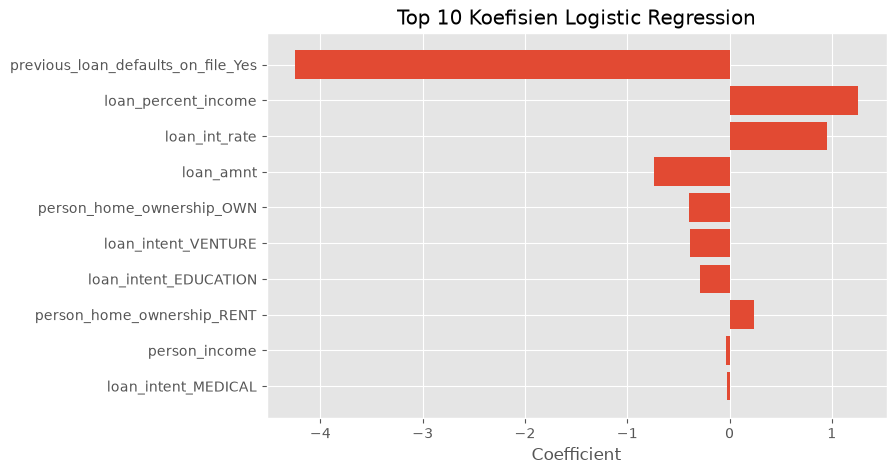

In [178]:
top10 = coef.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10["Feature"],
    top10["Coefficient"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Koefisien Logistic Regression")

plt.xlabel("Coefficient")

plt.show()

### Interpretasi

Berdasarkan nilai koefisien Logistic Regression, variabel **previous_loan_defaults_on_file_Yes** memiliki pengaruh paling besar terhadap hasil prediksi model dengan nilai koefisien sebesar **-4,25**. Besarnya nilai absolut koefisien menunjukkan bahwa fitur tersebut merupakan variabel yang paling berkontribusi dalam proses klasifikasi.



## 5.2 Random Forest

Random Forest merupakan algoritma klasifikasi yang membangun banyak decision tree untuk menghasilkan prediksi. Keputusan akhir diperoleh berdasarkan hasil voting dari seluruh pohon keputusan sehingga model mampu menghasilkan prediksi yang lebih stabil dan akurat.

### Parameter Model

Model Random Forest dibangun menggunakan parameter `n_estimators=100` dan `random_state=42`.

- `n_estimators=100` menunjukkan bahwa model membangun sebanyak 100 decision tree.
- `random_state=42` digunakan agar hasil pelatihan model tetap konsisten setiap kali program dijalankan.

In [179]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

### Hasil Training Model

Pada tahap ini dilakukan proses training menggunakan algoritma Random Forest terhadap data training yang telah melalui proses standardisasi.

In [180]:
rf.fit(X_train_scaled, y_train)

print("Training Random Forest berhasil dilakukan.")

Training Random Forest berhasil dilakukan.


### Interpretasi

Model Random Forest berhasil dilatih menggunakan data training sehingga siap digunakan untuk melakukan prediksi terhadap data testing.

In [181]:
from sklearn.metrics import accuracy_score

y_pred_rf = rf.predict(X_test_scaled)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Accuracy :", accuracy_rf)

Accuracy : 0.9248578954665188


### Interpretasi

Model Random Forest memperoleh nilai accuracy sebesar **92,49%**, yang berarti sekitar **92 dari 100 data testing** berhasil diklasifikasikan dengan benar. Nilai ini menunjukkan bahwa model memiliki performa yang sangat baik dalam memprediksi status persetujuan pinjaman.

### Confusion Matrix

Confusion Matrix digunakan untuk melihat jumlah prediksi benar maupun salah yang dilakukan model pada setiap kelas.

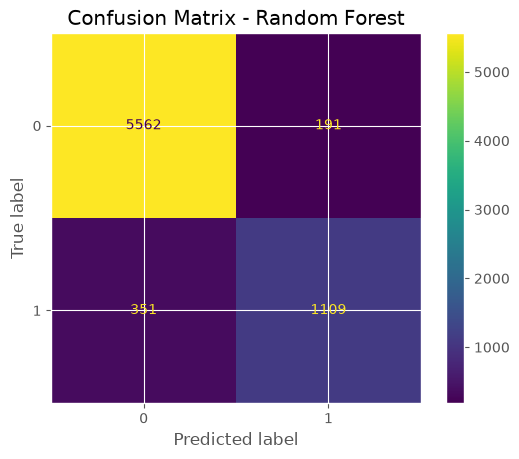

In [182]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)

plt.title("Confusion Matrix - Random Forest")

plt.show()

### Interpretasi

Berdasarkan Confusion Matrix, model Random Forest berhasil mengklasifikasikan **5.562** data kelas 0 dan **1.109** data kelas 1 dengan benar. Selain itu, terdapat **191** data yang termasuk False Positive dan **351** data yang termasuk False Negative. Hasil ini menunjukkan bahwa Random Forest mampu melakukan klasifikasi dengan tingkat kesalahan yang relatif rendah.

### Classification Report

Classification Report digunakan untuk mengevaluasi performa model berdasarkan metrik **precision**, **recall**, **f1-score**, dan **accuracy** pada masing-masing kelas.

In [183]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      5753
           1       0.85      0.76      0.80      1460

    accuracy                           0.92      7213
   macro avg       0.90      0.86      0.88      7213
weighted avg       0.92      0.92      0.92      7213



### Interpretasi

Berdasarkan Classification Report, model Random Forest memperoleh **accuracy sebesar 92,49%**.

Pada **kelas 0**, model memperoleh **precision 94%**, **recall 97%**, dan **F1-score 95%**, yang menunjukkan bahwa model sangat baik dalam mengidentifikasi pinjaman yang tidak bermasalah.

Pada **kelas 1**, model memperoleh **precision 85%**, **recall 76%**, dan **F1-score 80%**. Hasil ini menunjukkan bahwa model sudah mampu mengenali pinjaman bermasalah dengan baik, meskipun masih terdapat beberapa data yang belum berhasil terdeteksi.

Secara keseluruhan, nilai **weighted average F1-score sebesar 92%** menunjukkan bahwa Random Forest memiliki performa klasifikasi yang sangat baik.

### Specificity, Error Rate, False Positive Rate, dan False Negative Rate

Selain accuracy, evaluasi model juga dilakukan menggunakan metrik Specificity, Error Rate, False Positive Rate (FPR), dan False Negative Rate (FNR) untuk mengetahui kemampuan model dalam membedakan setiap kelas secara lebih rinci.

In [184]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

TN, FP, FN, TP = cm.ravel()

specificity = TN / (TN + FP)
error_rate = (FP + FN) / (TP + TN + FP + FN)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

print("Specificity :", specificity)
print("Error Rate :", error_rate)
print("False Positive Rate :", fpr)
print("False Negative Rate :", fnr)

Specificity : 0.9667999304710586
Error Rate : 0.07514210453348122
False Positive Rate : 0.033200069528941424
False Negative Rate : 0.2404109589041096


### Interpretasi

Model Random Forest memperoleh **Specificity sebesar 96,68%**, yang menunjukkan bahwa model sangat baik dalam mengenali data kelas negatif (kelas 0).

Nilai **Error Rate sebesar 7,51%** menunjukkan bahwa hanya sebagian kecil data yang mengalami kesalahan klasifikasi.

Selain itu, **False Positive Rate (FPR) sebesar 3,32%** menunjukkan bahwa jumlah data kelas negatif yang salah diprediksi sebagai positif relatif rendah.

Sementara itu, **False Negative Rate (FNR) sebesar 24,04%** menunjukkan bahwa masih terdapat sebagian data kelas positif yang belum berhasil dikenali oleh model, meskipun nilainya lebih baik dibandingkan Logistic Regression.

### ROC Curve dan ROC-AUC

ROC Curve digunakan untuk mengevaluasi kemampuan model dalam membedakan dua kelas pada berbagai nilai threshold. Nilai Area Under Curve (AUC) digunakan sebagai ukuran performa model secara keseluruhan.

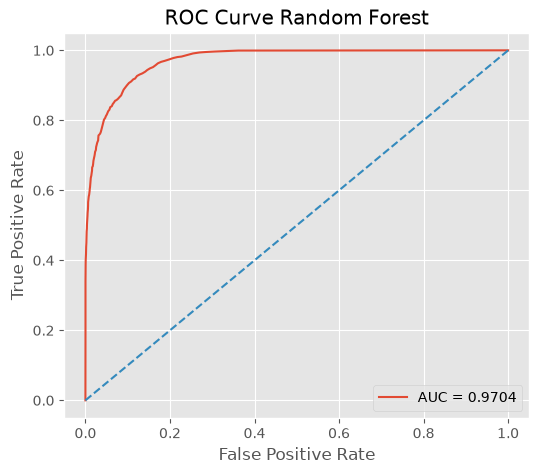

AUC Score : 0.9703903145232149


In [185]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr_rf, tpr_rf, label=f"AUC = {auc_rf:.4f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve Random Forest")

plt.legend()

plt.show()

print("AUC Score :", auc_rf)

### Interpretasi

Nilai ROC-AUC sebesar **0,9704** menunjukkan bahwa model Random Forest memiliki kemampuan yang sangat baik dalam membedakan antara pinjaman yang disetujui dan tidak disetujui. Nilai AUC yang mendekati 1 menunjukkan bahwa model mampu melakukan klasifikasi dengan tingkat akurasi yang sangat tinggi pada berbagai nilai threshold.

### Precision Recall Curve

Precision Recall Curve digunakan untuk mengevaluasi performa model, terutama pada dataset yang memiliki distribusi kelas yang tidak seimbang. Kurva ini menunjukkan hubungan antara nilai precision dan recall pada berbagai nilai threshold.

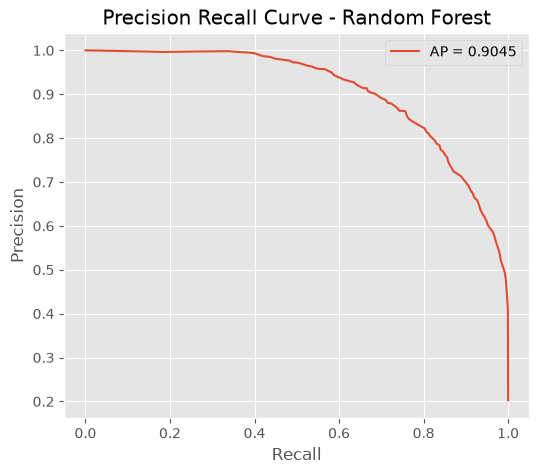

Average Precision : 0.9045146474519489


In [186]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

ap_rf = average_precision_score(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(recall_rf, precision_rf,
         label=f"AP = {ap_rf:.4f}")

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve - Random Forest")

plt.legend()

plt.show()

print("Average Precision :", ap_rf)

### Interpretasi

Nilai Average Precision (AP) sebesar **0.9045** menunjukkan bahwa model Random Forest mampu mempertahankan keseimbangan antara precision dan recall dengan sangat baik. Semakin mendekati nilai 1, semakin baik kemampuan model dalam mengidentifikasi kelas positif secara konsisten.

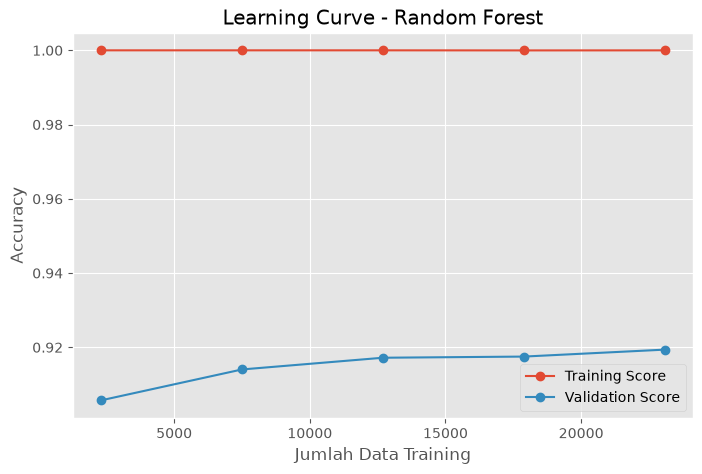

In [187]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    rf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, marker='o', label="Training Score")
plt.plot(train_sizes, test_mean, marker='o', label="Validation Score")

plt.xlabel("Jumlah Data Training")
plt.ylabel("Accuracy")
plt.title("Learning Curve - Random Forest")
plt.legend()

plt.show()

### Interpretasi

Berdasarkan Learning Curve, nilai akurasi pada data training dan validation cenderung stabil serta memiliki selisih yang kecil. Seiring bertambahnya jumlah data training, performa model pada data validation tetap berada pada rentang yang stabil dan mendekati performa data training.

Hal ini menunjukkan bahwa model Logistic Regression memiliki kemampuan generalisasi yang baik. Tidak terdapat perbedaan performa yang besar antara data training dan validation, sehingga model tidak menunjukkan indikasi overfitting maupun underfitting yang signifikan.

### Feature Importance

Random Forest menyediakan nilai feature importance yang menunjukkan tingkat kontribusi setiap fitur dalam proses pengambilan keputusan model. Semakin tinggi nilai feature importance, semakin besar pengaruh fitur tersebut terhadap hasil prediksi.

In [188]:
print("Jumlah kolom X :", len(X.columns))
print("Jumlah Feature Importance :", len(rf.feature_importances_))

Jumlah kolom X : 22
Jumlah Feature Importance : 10


### Fitur Terpilih

Berikut merupakan fitur-fitur yang dipilih menggunakan metode **SelectKBest** berdasarkan nilai skor tertinggi terhadap variabel target.

In [189]:
selected_features = X.columns[selector.get_support()]

print(selected_features)

Index(['person_income', 'loan_amnt', 'loan_int_rate', 'loan_percent_income',
       'person_home_ownership_OWN', 'person_home_ownership_RENT',
       'loan_intent_EDUCATION', 'loan_intent_MEDICAL', 'loan_intent_VENTURE',
       'previous_loan_defaults_on_file_Yes'],
      dtype='str')


### Interpretasi

Berdasarkan hasil Feature Selection menggunakan **SelectKBest**, dari **22 fitur** hasil proses encoding dipilih **10 fitur terbaik** yang memiliki hubungan paling kuat dengan variabel target (*loan_status*). Kesepuluh fitur tersebut kemudian digunakan pada proses pelatihan dan pengujian seluruh model Machine Learning, yaitu Logistic Regression, Random Forest, dan Support Vector Machine (SVM).

In [190]:
importance = pd.DataFrame({
    'Feature': selected_features,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
9,previous_loan_defaults_on_file_Yes,0.232794
2,loan_int_rate,0.217311
0,person_income,0.200282
3,loan_percent_income,0.170570
1,loan_amnt,0.090973
5,person_home_ownership_RENT,0.044721
6,loan_intent_EDUCATION,0.011324
4,person_home_ownership_OWN,0.010938
7,loan_intent_MEDICAL,0.010867
8,loan_intent_VENTURE,0.010220


### Feature Importance

Feature Importance digunakan untuk mengetahui tingkat pengaruh setiap fitur terhadap proses klasifikasi yang dilakukan oleh model Random Forest. Semakin besar nilai importance, semakin besar kontribusi fitur tersebut dalam menentukan hasil prediksi.

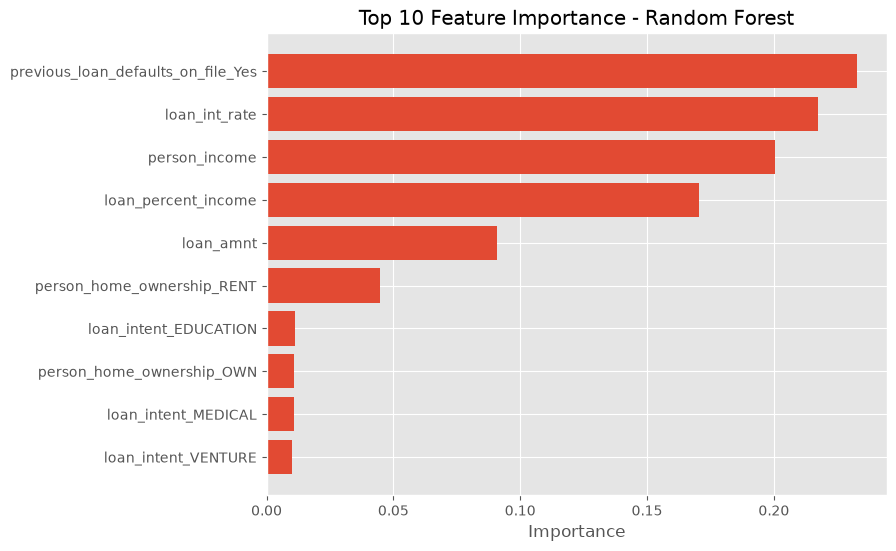

In [191]:
plt.figure(figsize=(8,6))

importance_top10 = importance.head(10)

plt.barh(
    importance_top10['Feature'][::-1],
    importance_top10['Importance'][::-1]
)

plt.xlabel("Importance")
plt.title("Top 10 Feature Importance - Random Forest")

plt.show()

### Interpretasi

Berdasarkan hasil Feature Importance, fitur **previous_loan_defaults_on_file_Yes** memiliki nilai importance tertinggi yaitu **0,2328**, sehingga menjadi faktor yang paling berpengaruh dalam menentukan status persetujuan pinjaman. Hal ini menunjukkan bahwa riwayat gagal bayar sebelumnya merupakan indikator utama yang digunakan model dalam melakukan klasifikasi.

Selain itu, fitur **loan_int_rate**, **person_income**, **loan_percent_income**, dan **loan_amnt** juga memberikan kontribusi yang cukup besar terhadap proses prediksi. Hal ini menunjukkan bahwa kondisi finansial peminjam serta karakteristik pinjaman memiliki peran penting dalam menentukan keputusan persetujuan pinjaman.

Sementara itu, fitur seperti **person_home_ownership** dan beberapa kategori **loan_intent** memiliki nilai importance yang lebih kecil, sehingga pengaruhnya terhadap hasil prediksi relatif lebih rendah dibandingkan fitur-fitur utama.

### Precision Recall Curve

Precision Recall Curve digunakan untuk mengevaluasi performa model, terutama pada dataset yang memiliki distribusi kelas yang tidak seimbang. Kurva ini menunjukkan hubungan antara nilai precision dan recall pada berbagai nilai threshold.

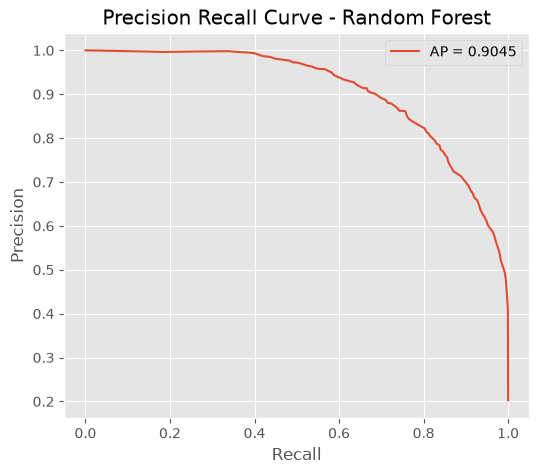

Average Precision : 0.9045146474519489


In [192]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

precision_rf, recall_rf, _ = precision_recall_curve(
    y_test,
    y_prob_rf
)

ap_rf = average_precision_score(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(6,5))

plt.plot(
    recall_rf,
    precision_rf,
    label=f"AP = {ap_rf:.4f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision Recall Curve - Random Forest")

plt.legend()

plt.show()

print("Average Precision :", ap_rf)

### Interpretasi

Nilai **Average Precision (AP) sebesar 0,9045** menunjukkan bahwa model Random Forest mampu mempertahankan keseimbangan antara nilai precision dan recall dengan sangat baik. Semakin mendekati nilai 1, semakin baik kemampuan model dalam mengidentifikasi kelas positif secara konsisten. Hasil ini menunjukkan bahwa model memiliki performa yang sangat baik dalam membedakan status persetujuan pinjaman.

### Learning Curve

Learning Curve digunakan untuk mengetahui bagaimana performa model berubah seiring bertambahnya jumlah data training. Grafik ini juga dapat digunakan untuk mendeteksi indikasi overfitting maupun underfitting.

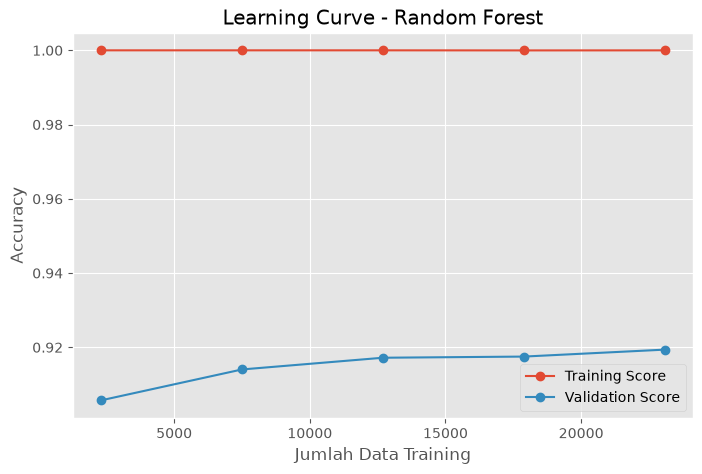

In [193]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    rf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1,1.0,5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training Score'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation Score'
)

plt.xlabel("Jumlah Data Training")
plt.ylabel("Accuracy")

plt.title("Learning Curve - Random Forest")

plt.legend()

plt.show()

### Interpretasi

Learning Curve menunjukkan hubungan antara jumlah data training dengan performa model. Apabila kurva training dan validation semakin mendekat serta cenderung stabil, maka model memiliki kemampuan generalisasi yang baik dan tidak menunjukkan indikasi overfitting yang signifikan.

## 5.3 Support Vector Machine (SVM)

Support Vector Machine (SVM) merupakan algoritma klasifikasi yang bekerja dengan mencari hyperplane terbaik untuk memisahkan data ke dalam dua kelas. Algoritma ini efektif digunakan pada permasalahan klasifikasi karena mampu memaksimalkan jarak (margin) antar kelas sehingga menghasilkan model yang memiliki kemampuan generalisasi yang baik.

### Parameter Model

Model Support Vector Machine dibangun menggunakan kernel **linear** dengan parameter `probability=True` agar model dapat menghasilkan probabilitas prediksi yang diperlukan untuk evaluasi ROC Curve dan Precision Recall Curve. Parameter `random_state=42` digunakan agar hasil pelatihan model dapat direproduksi.

In [194]:
from sklearn.svm import SVC

svm = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

svm.fit(X_train_scaled, y_train)

c:\Users\TEGAR\Documents\Sakti\Loan_Approval_ML\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


### Prediksi

Setelah proses pelatihan selesai, model digunakan untuk memprediksi data testing serta menghitung probabilitas setiap kelas.

In [195]:
y_pred_svm = svm.predict(X_test_scaled)

y_prob_svm = svm.predict_proba(X_test_scaled)[:,1]

### Accuracy

Accuracy digunakan untuk mengukur persentase prediksi yang benar terhadap seluruh data pengujian.

In [196]:
accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

print("Accuracy :", accuracy_svm)

Accuracy : 0.892139193123527


### Confusion Matrix

Confusion Matrix digunakan untuk mengevaluasi hasil prediksi model dengan membandingkan kelas aktual dan kelas hasil prediksi.

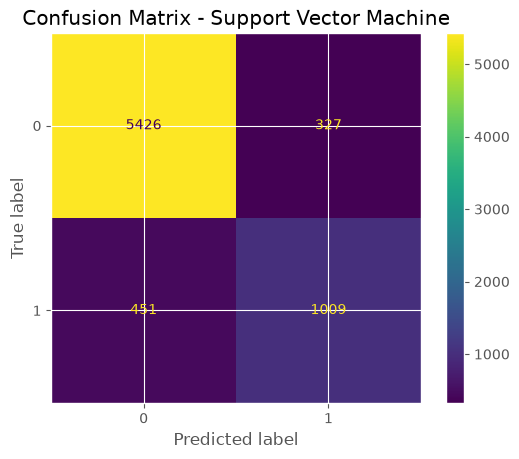

In [197]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm
)

plt.title("Confusion Matrix - Support Vector Machine")

plt.show()

### Interpretasi

Confusion Matrix menunjukkan jumlah prediksi yang benar maupun salah yang dihasilkan oleh model Support Vector Machine. Nilai pada diagonal utama menunjukkan jumlah data yang berhasil diklasifikasikan dengan benar, sedangkan nilai di luar diagonal menunjukkan kesalahan klasifikasi. Semakin besar jumlah prediksi yang benar dan semakin sedikit kesalahan prediksi, maka semakin baik performa model dalam mengklasifikasikan status persetujuan pinjaman.

### Classification Report

Classification Report digunakan untuk mengevaluasi performa model menggunakan metrik precision, recall, F1-score, dan accuracy.

In [198]:
print(classification_report(
    y_test,
    y_pred_svm
))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93      5753
           1       0.76      0.69      0.72      1460

    accuracy                           0.89      7213
   macro avg       0.84      0.82      0.83      7213
weighted avg       0.89      0.89      0.89      7213



### Interpretasi

Berdasarkan hasil Classification Report, model Support Vector Machine memperoleh **accuracy sebesar 89%**. Untuk kelas **0 (pinjaman tidak bermasalah)**, model menghasilkan **precision sebesar 92%**, **recall sebesar 94%**, dan **F1-score sebesar 93%**, yang menunjukkan kemampuan klasifikasi yang sangat baik.

Sementara itu, untuk kelas **1 (pinjaman bermasalah)**, model memperoleh **precision sebesar 76%**, **recall sebesar 69%**, dan **F1-score sebesar 72%**. Hal ini menunjukkan bahwa model masih mengalami beberapa kesalahan dalam mengidentifikasi pinjaman bermasalah, terutama karena nilai recall yang lebih rendah dibandingkan kelas 0.

Secara keseluruhan, model memiliki performa yang baik dalam melakukan klasifikasi, namun kemampuan mendeteksi kelas positif masih dapat ditingkatkan.

### Specificity, Error Rate, False Positive Rate, dan False Negative Rate

Selain accuracy, evaluasi model juga dilakukan menggunakan metrik Specificity, Error Rate, False Positive Rate (FPR), dan False Negative Rate (FNR) untuk mengetahui kemampuan model dalam membedakan setiap kelas secara lebih rinci.

In [199]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_svm
)

TN, FP, FN, TP = cm.ravel()

specificity = TN / (TN + FP)
error_rate = (FP + FN) / (TP + TN + FP + FN)
fpr = FP / (FP + TN)
fnr = FN / (FN + TP)

print("Specificity :", specificity)
print("Error Rate  :", error_rate)
print("False Positive Rate :", fpr)
print("False Negative Rate :", fnr)

Specificity : 0.9431600903876238
Error Rate  : 0.10786080687647304
False Positive Rate : 0.05683990961237615
False Negative Rate : 0.3089041095890411


### Interpretasi

Berdasarkan hasil evaluasi, model Support Vector Machine memperoleh **Specificity sebesar 0,9432**, yang menunjukkan bahwa model mampu mengidentifikasi kelas negatif dengan sangat baik, yaitu sekitar **94,32%**.

Nilai **Error Rate sebesar 0,1079** menunjukkan bahwa sekitar **10,79%** dari seluruh data pengujian masih mengalami kesalahan klasifikasi. Selain itu, **False Positive Rate sebesar 0,0568** menunjukkan bahwa sekitar **5,68%** data yang sebenarnya termasuk kelas negatif salah diprediksi sebagai kelas positif.

Sementara itu, **False Negative Rate sebesar 0,3089** menunjukkan bahwa sekitar **30,89%** data yang sebenarnya termasuk kelas positif masih salah diprediksi sebagai kelas negatif. Nilai ini mengindikasikan bahwa model masih memiliki kelemahan dalam mendeteksi pinjaman bermasalah, sehingga beberapa kasus positif belum berhasil teridentifikasi dengan baik.

### ROC Curve dan ROC-AUC

ROC Curve digunakan untuk mengevaluasi kemampuan model dalam membedakan dua kelas pada berbagai nilai threshold. Nilai Area Under Curve (AUC) digunakan sebagai ukuran performa model secara keseluruhan.

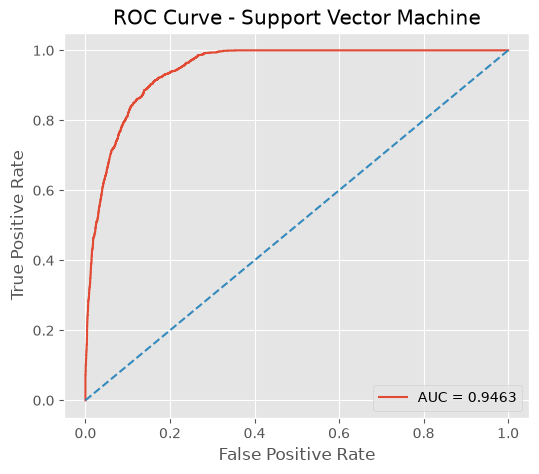

AUC Score : 0.9462648433574858


In [200]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

auc_svm = roc_auc_score(y_test, y_prob_svm)

plt.figure(figsize=(6,5))

plt.plot(fpr_svm, tpr_svm, label=f"AUC = {auc_svm:.4f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Support Vector Machine")

plt.legend()

plt.show()

print("AUC Score :", auc_svm)

### Interpretasi

Nilai **ROC-AUC sebesar 0,9463** menunjukkan kemampuan model Support Vector Machine dalam membedakan antara pinjaman yang disetujui dan tidak disetujui. Semakin mendekati nilai 1, semakin baik kemampuan model dalam melakukan klasifikasi. Berdasarkan hasil tersebut, model memiliki kemampuan klasifikasi yang **sangat baik**.

### Precision Recall Curve

Precision Recall Curve digunakan untuk mengevaluasi performa model, terutama pada dataset yang memiliki distribusi kelas yang tidak seimbang. Kurva ini menunjukkan hubungan antara nilai precision dan recall pada berbagai nilai threshold.

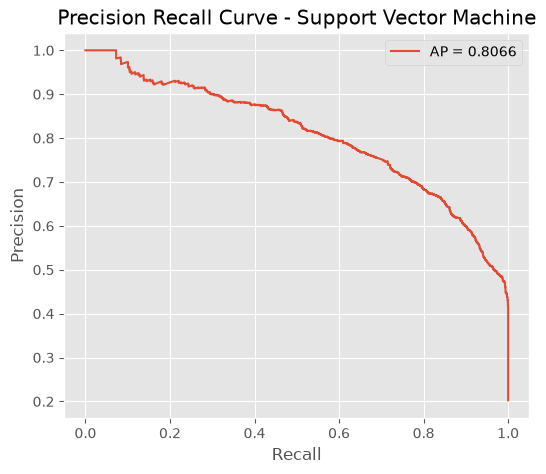

Average Precision : 0.8065578877113732


In [201]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

precision_svm, recall_svm, _ = precision_recall_curve(
    y_test,
    y_prob_svm
)

ap_svm = average_precision_score(
    y_test,
    y_prob_svm
)

plt.figure(figsize=(6,5))

plt.plot(
    recall_svm,
    precision_svm,
    label=f"AP = {ap_svm:.4f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision Recall Curve - Support Vector Machine")

plt.legend()

plt.show()

print("Average Precision :", ap_svm)

### Interpretasi

Nilai **Average Precision (AP) sebesar 0,8066** menunjukkan bahwa model Support Vector Machine mampu mempertahankan keseimbangan antara nilai precision dan recall dengan baik. Semakin mendekati nilai 1, semakin baik kemampuan model dalam mengidentifikasi kelas positif secara konsisten.

### Learning Curve

Learning Curve digunakan untuk mengetahui bagaimana performa model berubah seiring bertambahnya jumlah data training. Grafik ini juga dapat digunakan untuk mendeteksi indikasi overfitting maupun underfitting.

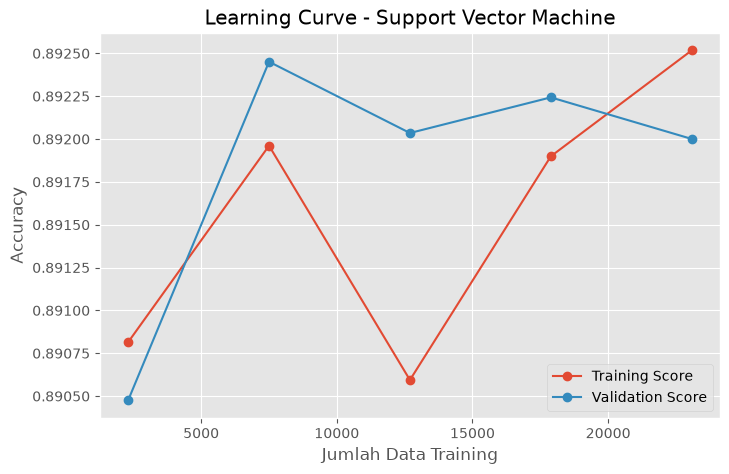

In [202]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    svm,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1,1.0,5),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='Training Score'
)

plt.plot(
    train_sizes,
    val_mean,
    marker='o',
    label='Validation Score'
)

plt.xlabel("Jumlah Data Training")

plt.ylabel("Accuracy")

plt.title("Learning Curve - Support Vector Machine")

plt.legend()

plt.show()

### Interpretasi

Learning Curve menunjukkan hubungan antara jumlah data training dengan performa model Support Vector Machine. Seiring bertambahnya jumlah data training, nilai accuracy pada data training maupun validation cenderung stabil. Hal ini menunjukkan bahwa model memiliki kemampuan generalisasi yang baik dan tidak menunjukkan indikasi overfitting yang signifikan.

#  6 Improvement

Pada tahap ini dilakukan beberapa teknik improvement untuk meningkatkan performa model Machine Learning serta mengevaluasi kestabilan model dalam melakukan prediksi. Teknik improvement yang digunakan meliputi Cross Validation, Hyperparameter Tuning, Data Balancing (SMOTE), Class Weight, dan Threshold Tuning.

## 6.1 Cross Validation

Cross Validation digunakan untuk mengevaluasi kestabilan model dengan membagi data training menjadi beberapa fold. Teknik ini membantu mengurangi risiko overfitting dan memberikan estimasi performa model yang lebih representatif dibandingkan hanya menggunakan satu kali pembagian data training dan testing.

### Logistic Regression

In [203]:
from sklearn.model_selection import cross_val_score

cv_lr = cross_val_score(
    lr,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(cv_lr)

print("Mean Accuracy :", cv_lr.mean())

[0.892393   0.89308612 0.88804159 0.89393414 0.89220104]
Mean Accuracy : 0.8919311792332847


### Interpretasi

Hasil 5-Fold Cross Validation pada model Logistic Regression menghasilkan rata-rata accuracy sebesar **89,19%**. Nilai accuracy pada setiap fold relatif konsisten, sehingga menunjukkan bahwa model memiliki kemampuan generalisasi yang baik dan tidak bergantung pada satu pembagian data tertentu.

### Random Forest

In [204]:
cv_rf = cross_val_score(
    rf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(cv_rf)

print("Mean Accuracy :", cv_rf.mean())

[0.92081095 0.92133079 0.91299827 0.92149047 0.91906412]
Mean Accuracy : 0.9191389205634939


### Interpretasi

Hasil 5-Fold Cross Validation menunjukkan bahwa Random Forest memperoleh rata-rata accuracy sebesar **91,91%**, yang merupakan nilai tertinggi dibandingkan model lainnya. Selain itu, nilai accuracy pada setiap fold relatif konsisten sehingga menunjukkan bahwa model memiliki performa yang stabil dan mampu melakukan generalisasi dengan baik terhadap data baru.

### Support Vector Machine

In [205]:
cv_svm = cross_val_score(
    svm,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(cv_svm)

print("Mean Accuracy :", cv_svm.mean())

c:\Users\TEGAR\Documents\Sakti\Loan_Approval_ML\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\TEGAR\Documents\Sakti\Loan_Approval_ML\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\TEGAR\Documents\Sakti\Loan_Approval_ML\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\TEGAR\Documents\Sakti\Loan_Approval_ML\venv\Lib\site-packages\sklearn\svm\_base.py

[0.89135332 0.8941258  0.88804159 0.8932409  0.89341421]
Mean Accuracy : 0.8920351653684667


### Interpretasi

Model Support Vector Machine memperoleh rata-rata accuracy sebesar **89,20%** pada proses 5-Fold Cross Validation. Hasil ini menunjukkan bahwa model memiliki performa yang cukup stabil pada setiap fold, meskipun nilai accuracy yang diperoleh masih lebih rendah dibandingkan Random Forest.

### Tabel Perbandingan

In [206]:
cv_result = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Support Vector Machine"
    ],
    "Mean Accuracy":[
        cv_lr.mean(),
        cv_rf.mean(),
        cv_svm.mean()
    ]
})

cv_result

,Model,Mean Accuracy
0,Logistic Regression,0.891931
1,Random Forest,0.919139
2,Support Vector Machine,0.892035


### Interpretasi

Berdasarkan hasil Cross Validation, **Random Forest** memperoleh rata-rata accuracy tertinggi sebesar **91,91%**, diikuti oleh **Support Vector Machine** sebesar **89,20%**, dan **Logistic Regression** sebesar **89,19%**. Hasil ini menunjukkan bahwa Random Forest merupakan model yang paling stabil dan memiliki kemampuan generalisasi terbaik pada dataset prediksi persetujuan pinjaman.

## 6.2 Hyperparameter Tuning

Hyperparameter Tuning dilakukan untuk mencari kombinasi parameter terbaik pada setiap algoritma Machine Learning. Proses ini bertujuan untuk meningkatkan performa model dengan mencoba berbagai kombinasi parameter menggunakan teknik Grid Search dan Cross Validation.

### Logistic Regression

Hyperparameter Tuning pada Logistic Regression dilakukan menggunakan GridSearchCV untuk mencari kombinasi parameter terbaik berdasarkan nilai accuracy.

In [207]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=param_lr,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_lr.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informati

In [208]:
print("Best Parameter :", grid_lr.best_params_)

print("Best CV Score :", grid_lr.best_score_)

Best Parameter : {'C': 1, 'solver': 'lbfgs'}
Best CV Score : 0.8919311792332847


In [209]:
best_lr = grid_lr.best_estimator_

y_pred_best_lr = best_lr.predict(X_test_scaled)

accuracy_best_lr = accuracy_score(
    y_test,
    y_pred_best_lr
)

print("Accuracy Setelah Tuning :", accuracy_best_lr)

Accuracy Setelah Tuning : 0.8903368917232775


### Interpretasi

Hasil Hyperparameter Tuning pada Logistic Regression menunjukkan bahwa kombinasi parameter terbaik adalah **C = 1** dan **solver = 'lbfgs'**, yang merupakan parameter default dari algoritma Logistic Regression. Nilai rata-rata accuracy pada proses Cross Validation sebesar **89,19%**, sedangkan accuracy pada data testing setelah tuning sebesar **89,03%**.



### Random Forest

Hyperparameter Tuning pada Random Forest dilakukan menggunakan GridSearchCV untuk memperoleh kombinasi parameter terbaik sehingga model dapat menghasilkan performa klasifikasi yang lebih optimal.

In [210]:
from sklearn.ensemble import RandomForestClassifier

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Control

In [211]:
print("Best Parameter :", grid_rf.best_params_)

print("Best CV Score :", grid_rf.best_score_)

Best Parameter : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score : 0.9214264773938418


In [212]:
best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test_scaled)

accuracy_best_rf = accuracy_score(
    y_test,
    y_pred_best_rf
)

print("Accuracy Setelah Tuning :", accuracy_best_rf)

Accuracy Setelah Tuning : 0.9252738111742687


### Interpretasi

Hasil Hyperparameter Tuning menunjukkan bahwa kombinasi parameter terbaik pada Random Forest adalah **n_estimators = 200**, **max_depth = None**, dan **min_samples_split = 5**. Parameter tersebut menghasilkan rata-rata accuracy Cross Validation sebesar **92,14%**.

Setelah model diuji menggunakan data testing, accuracy meningkat dari **92,49%** menjadi **92,53%**. Hasil ini menunjukkan bahwa proses Hyperparameter Tuning berhasil meningkatkan performa model meskipun peningkatannya relatif kecil. 

### Support Vector Machine

Hyperparameter Tuning pada Support Vector Machine dilakukan menggunakan GridSearchCV untuk menentukan kombinasi parameter yang menghasilkan performa klasifikasi terbaik.

In [213]:
from sklearn.svm import SVC

param_svm = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid=param_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_train_scaled, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(random_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of

In [214]:
print("Best Parameter :", grid_svm.best_params_)

print("Best CV Score :", grid_svm.best_score_)

Best Parameter : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score : 0.9096424571912332


In [215]:
best_svm = grid_svm.best_estimator_

y_pred_best_svm = best_svm.predict(X_test_scaled)

accuracy_best_svm = accuracy_score(
    y_test,
    y_pred_best_svm
)

print("Accuracy Setelah Tuning :", accuracy_best_svm)

Accuracy Setelah Tuning : 0.9112713156800222


### Interpretasi

Hasil Hyperparameter Tuning menunjukkan bahwa kombinasi parameter terbaik pada Support Vector Machine adalah **kernel = rbf**, **C = 10**, dan **gamma = scale**. Kombinasi parameter tersebut menghasilkan rata-rata accuracy Cross Validation sebesar **90,96%**.

Setelah dilakukan pengujian pada data testing, accuracy model meningkat dari **89,21%** menjadi **91,13%**. Hal ini menunjukkan bahwa proses Hyperparameter Tuning berhasil meningkatkan kemampuan model dalam melakukan klasifikasi sehingga performa Support Vector Machine menjadi lebih baik dibandingkan sebelum tuning.

In [216]:
tuning_result = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Support Vector Machine"
    ],
    "Accuracy Sebelum Tuning": [
        accuracy_lr,
        accuracy_rf,
        accuracy_svm
    ],
    "Accuracy Setelah Tuning": [
        accuracy_best_lr,
        accuracy_best_rf,
        accuracy_best_svm
    ]
})

tuning_result

,Model,Accuracy Sebelum Tuning,Accuracy Setelah Tuning
0,Logistic Regression,0.890337,0.890337
1,Random Forest,0.924858,0.925274
2,Support Vector Machine,0.892139,0.911271


### Interpretasi

Berdasarkan hasil Hyperparameter Tuning, setiap algoritma menunjukkan perubahan performa yang berbeda. Logistic Regression tidak mengalami peningkatan karena parameter default yang digunakan telah cukup optimal untuk dataset. Random Forest mengalami peningkatan accuracy dari **92,49%** menjadi **92,53%**, sedangkan Support Vector Machine mengalami peningkatan yang lebih signifikan dari **89,21%** menjadi **91,13%**.

Hasil tersebut menunjukkan bahwa Hyperparameter Tuning mampu meningkatkan performa beberapa algoritma, terutama Support Vector Machine.

## 6.3 Data Balancing (SMOTE)

Data Balancing dilakukan menggunakan teknik **Synthetic Minority Over sampling Technique (SMOTE)**. Teknik ini bertujuan untuk mengatasi ketidakseimbangan jumlah data pada setiap kelas dengan membuat data sintetis pada kelas minoritas sehingga distribusi kelas menjadi lebih seimbang. Diharapkan model dapat mengenali kelas minoritas dengan lebih baik setelah proses balancing.

### Distribusi Kelas Sebelum SMOTE

Sebelum dilakukan proses Data Balancing, lakukan pengecekan distribusi kelas untuk mengetahui tingkat ketidakseimbangan data.

In [217]:
print(y_train.value_counts())

loan_status
0    23023
1     5829
Name: count, dtype: int64


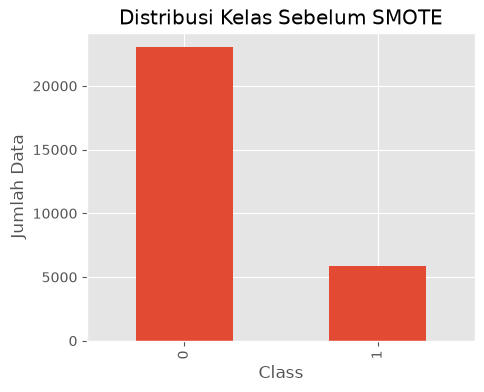

In [218]:
plt.figure(figsize=(5,4))

y_train.value_counts().plot(
    kind='bar'
)

plt.title("Distribusi Kelas Sebelum SMOTE")

plt.xlabel("Class")

plt.ylabel("Jumlah Data")

plt.show()

### Interpretasi

Distribusi kelas menunjukkan bahwa jumlah data pada kelas mayoritas lebih banyak dibandingkan kelas minoritas. Kondisi ini menunjukkan bahwa dataset bersifat **imbalanced**, sehingga model berpotensi lebih banyak mempelajari pola pada kelas mayoritas dibandingkan kelas minoritas.

### Proses SMOTE

Pada tahap ini dilakukan proses oversampling menggunakan SMOTE untuk menambah jumlah data pada kelas minoritas sehingga distribusi kedua kelas menjadi lebih seimbang.

In [219]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [220]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [221]:
print(y_train_smote.value_counts())

loan_status
0    23023
1    23023
Name: count, dtype: int64


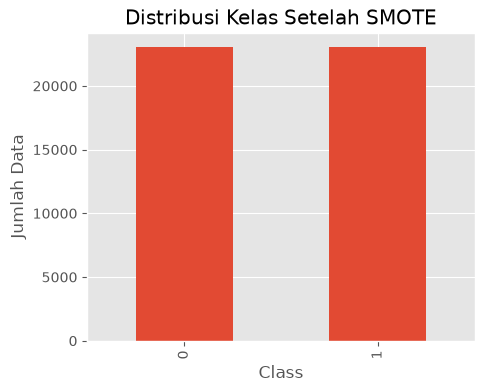

In [222]:
plt.figure(figsize=(5,4))

y_train_smote.value_counts().plot(
    kind='bar'
)

plt.title("Distribusi Kelas Setelah SMOTE")

plt.xlabel("Class")

plt.ylabel("Jumlah Data")

plt.show()

### Interpretasi

Setelah dilakukan proses SMOTE, jumlah data pada kelas mayoritas dan kelas minoritas menjadi seimbang. Dengan distribusi kelas yang lebih seimbang, model diharapkan mampu mempelajari karakteristik kedua kelas secara lebih baik sehingga kemampuan dalam mendeteksi kelas minoritas dapat meningkat.

### Logistic Regression + SMOTE

In [223]:
lr_smote = LogisticRegression(
    random_state=42
)

lr_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_lr_smote = lr_smote.predict(
    X_test_scaled
)

accuracy_lr_smote = accuracy_score(
    y_test,
    y_pred_lr_smote
)

print("Accuracy :", accuracy_lr_smote)

print(classification_report(
    y_test,
    y_pred_lr_smote
))

Accuracy : 0.8426452239012894
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      5753
           1       0.57      0.92      0.70      1460

    accuracy                           0.84      7213
   macro avg       0.77      0.87      0.80      7213
weighted avg       0.89      0.84      0.85      7213



### Interpretasi

Setelah diterapkan SMOTE pada Logistic Regression, model dievaluasi kembali menggunakan data testing. Perubahan nilai accuracy maupun recall menunjukkan pengaruh proses Data Balancing terhadap kemampuan model dalam mengenali kelas minoritas.

### Random Forest + SMOTE

In [224]:
rf_smote = RandomForestClassifier(
    random_state=42
)

rf_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_rf_smote = rf_smote.predict(
    X_test_scaled
)

accuracy_rf_smote = accuracy_score(
    y_test,
    y_pred_rf_smote
)

print("Accuracy :", accuracy_rf_smote)

print(classification_report(
    y_test,
    y_pred_rf_smote
))

Accuracy : 0.9112713156800222
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      5753
           1       0.75      0.83      0.79      1460

    accuracy                           0.91      7213
   macro avg       0.86      0.88      0.87      7213
weighted avg       0.92      0.91      0.91      7213



### Interpretasi

Random Forest kemudian dilatih menggunakan data hasil SMOTE untuk mengetahui apakah proses Data Balancing mampu meningkatkan kemampuan model dalam mengidentifikasi kelas minoritas tanpa menurunkan performa keseluruhan secara signifikan.

### Support Vector Machine + SMOTE

In [225]:
svm_smote = SVC(
    probability=True,
    random_state=42
)

svm_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_svm_smote = svm_smote.predict(
    X_test_scaled
)

accuracy_svm_smote = accuracy_score(
    y_test,
    y_pred_svm_smote
)

print("Accuracy :", accuracy_svm_smote)

print(classification_report(
    y_test,
    y_pred_svm_smote
))

c:\Users\TEGAR\Documents\Sakti\Loan_Approval_ML\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Accuracy : 0.8420906696242895
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      5753
           1       0.57      0.95      0.71      1460

    accuracy                           0.84      7213
   macro avg       0.77      0.88      0.80      7213
weighted avg       0.90      0.84      0.85      7213



### Interpretasi

Support Vector Machine juga dievaluasi menggunakan data hasil SMOTE untuk melihat perubahan performa klasifikasi setelah distribusi kelas menjadi lebih seimbang.

In [226]:
smote_result = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Support Vector Machine"
    ],
    "Accuracy Sebelum SMOTE":[
        accuracy_best_lr,
        accuracy_best_rf,
        accuracy_best_svm
    ],
    "Accuracy Setelah SMOTE":[
        accuracy_lr_smote,
        accuracy_rf_smote,
        accuracy_svm_smote
    ]
})

smote_result

,Model,Accuracy Sebelum SMOTE,Accuracy Setelah SMOTE
0,Logistic Regression,0.890337,0.842645
1,Random Forest,0.925274,0.911271
2,Support Vector Machine,0.911271,0.842091


### Interpretasi

Tabel di atas menunjukkan perbandingan performa model sebelum dan sesudah penerapan SMOTE. Selain memperhatikan perubahan accuracy, evaluasi juga perlu difokuskan pada perubahan nilai **recall kelas minoritas**, karena tujuan utama SMOTE adalah meningkatkan kemampuan model dalam mengenali kelas yang sebelumnya memiliki jumlah data lebih sedikit.

In [227]:
classification_report

<function sklearn.metrics._classification.classification_report(y_true, y_pred, *, labels=None, target_names=None, sample_weight=None, digits=2, output_dict=False, zero_division='warn')>

### Logistic Regression + SMOTE

In [228]:
print(classification_report(y_test, y_pred_lr_smote))

              precision    recall  f1-score   support

           0       0.98      0.82      0.89      5753
           1       0.57      0.92      0.70      1460

    accuracy                           0.84      7213
   macro avg       0.77      0.87      0.80      7213
weighted avg       0.89      0.84      0.85      7213



### Interpretasi

Setelah diterapkan SMOTE, accuracy Logistic Regression menurun dari **89,03%** menjadi **84,26%**. Namun, nilai **recall kelas minoritas meningkat dari 70% menjadi 92%**. Hal ini menunjukkan bahwa model menjadi jauh lebih baik dalam mengenali data pada kelas minoritas, meskipun harus mengorbankan sebagian nilai accuracy dan precision.

### Random Forest + SMOTE

In [229]:
print(classification_report(y_test, y_pred_rf_smote))

              precision    recall  f1-score   support

           0       0.96      0.93      0.94      5753
           1       0.75      0.83      0.79      1460

    accuracy                           0.91      7213
   macro avg       0.86      0.88      0.87      7213
weighted avg       0.92      0.91      0.91      7213



### Interpretasi

Pada Random Forest, accuracy menurun dari **92,53%** menjadi **91,13%** setelah penerapan SMOTE. Meskipun demikian, **recall kelas minoritas meningkat dari 76% menjadi 83%**, sehingga model menjadi lebih mampu mendeteksi kelas minoritas. Penurunan accuracy relatif kecil dibandingkan peningkatan kemampuan klasifikasi terhadap kelas minoritas.

### SVM + SMOTE

In [230]:
print(classification_report(y_test, y_pred_svm_smote))

              precision    recall  f1-score   support

           0       0.98      0.82      0.89      5753
           1       0.57      0.95      0.71      1460

    accuracy                           0.84      7213
   macro avg       0.77      0.88      0.80      7213
weighted avg       0.90      0.84      0.85      7213



### Interpretasi

Penerapan SMOTE pada Support Vector Machine menyebabkan accuracy menurun dari **91,13%** menjadi **84,21%**. Namun demikian, **recall kelas minoritas meningkat dari 69% menjadi 95%**. Hal ini menunjukkan bahwa model menjadi sangat baik dalam mendeteksi kelas minoritas, tetapi menghasilkan lebih banyak prediksi positif yang salah sehingga accuracy dan precision menurun.

In [231]:
report_lr = classification_report(y_test, y_pred_lr_smote, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf_smote, output_dict=True)
report_svm = classification_report(y_test, y_pred_svm_smote, output_dict=True)

smote_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Support Vector Machine"
    ],
    "Accuracy": [
        accuracy_lr_smote,
        accuracy_rf_smote,
        accuracy_svm_smote
    ],
    "Precision (Kelas 1)": [
        report_lr['1']['precision'],
        report_rf['1']['precision'],
        report_svm['1']['precision']
    ],
    "Recall (Kelas 1)": [
        report_lr['1']['recall'],
        report_rf['1']['recall'],
        report_svm['1']['recall']
    ],
    "F1-score (Kelas 1)": [
        report_lr['1']['f1-score'],
        report_rf['1']['f1-score'],
        report_svm['1']['f1-score']
    ]
})

smote_comparison

,Model,Accuracy,Precision (Kelas 1),Recall (Kelas 1),F1-score (Kelas 1)
0,Logistic Regression,0.842645,0.568479,0.923973,0.703887
1,Random Forest,0.911271,0.754342,0.832877,0.791667
2,Support Vector Machine,0.842091,0.565752,0.945890,0.708024


### Interpretasi

Berdasarkan tabel perbandingan, penerapan SMOTE memberikan dampak yang berbeda pada setiap algoritma. Secara umum, nilai **accuracy** mengalami penurunan, namun **recall kelas minoritas meningkat** pada seluruh model. Hal ini menunjukkan bahwa model menjadi lebih mampu mengenali data pada kelas minoritas setelah distribusi data diseimbangkan.

Logistic Regression memperoleh recall sebesar **92,40%**, sedangkan Support Vector Machine memperoleh recall tertinggi yaitu **94,59%**. Namun, kedua model mengalami penurunan accuracy dan precision yang cukup besar. Di sisi lain, Random Forest memberikan keseimbangan performa terbaik dengan accuracy sebesar **91,13%**, precision **75,43%**, recall **83,29%**, dan F1-score **79,17%**. Oleh karena itu, Random Forest tetap menjadi algoritma yang paling optimal setelah penerapan SMOTE.

## 6.4 Class Weight

Class Weight merupakan teknik untuk mengatasi ketidakseimbangan data tanpa menambah ataupun mengurangi jumlah data. Teknik ini bekerja dengan memberikan bobot yang lebih besar pada kelas minoritas sehingga model akan memberikan perhatian lebih saat proses pelatihan.

### Logistic Regression dengan Class Weight

Pada tahap ini Logistic Regression dilatih kembali menggunakan parameter `class_weight='balanced'` agar model memberikan perhatian yang sama terhadap setiap kelas.

In [232]:
lr_weight = LogisticRegression(
    class_weight='balanced',
    random_state=42
)

lr_weight.fit(
    X_train_scaled,
    y_train
)

y_pred_lr_weight = lr_weight.predict(
    X_test_scaled
)

accuracy_lr_weight = accuracy_score(
    y_test,
    y_pred_lr_weight
)

print("Accuracy :", accuracy_lr_weight)

print(classification_report(
    y_test,
    y_pred_lr_weight
))

Accuracy : 0.84028836822404
              precision    recall  f1-score   support

           0       0.98      0.82      0.89      5753
           1       0.56      0.93      0.70      1460

    accuracy                           0.84      7213
   macro avg       0.77      0.87      0.80      7213
weighted avg       0.89      0.84      0.85      7213



### Interpretasi

Penerapan Class Weight pada Logistic Regression meningkatkan kemampuan model dalam mengenali kelas minoritas. Hal ini ditunjukkan oleh peningkatan recall dari **70% menjadi 93%**. Namun demikian, accuracy menurun menjadi **84,03%** dan precision juga mengalami penurunan. Hal ini menunjukkan bahwa model menjadi lebih sensitif terhadap kelas minoritas, tetapi menghasilkan lebih banyak prediksi positif yang salah.

### Random Forest dengan Class Weight

Random Forest kemudian dilatih menggunakan parameter `class_weight='balanced'` untuk meningkatkan kemampuan model dalam mengenali kelas minoritas.

In [233]:
rf_weight = RandomForestClassifier(
    class_weight='balanced',
    random_state=42
)

rf_weight.fit(
    X_train_scaled,
    y_train
)

y_pred_rf_weight = rf_weight.predict(
    X_test_scaled
)

accuracy_rf_weight = accuracy_score(
    y_test,
    y_pred_rf_weight
)

print("Accuracy :", accuracy_rf_weight)

print(classification_report(
    y_test,
    y_pred_rf_weight
))

Accuracy : 0.9143213642035214
              precision    recall  f1-score   support

           0       0.96      0.93      0.95      5753
           1       0.76      0.85      0.80      1460

    accuracy                           0.91      7213
   macro avg       0.86      0.89      0.87      7213
weighted avg       0.92      0.91      0.92      7213



### Interpretasi

Pada Random Forest, penerapan Class Weight meningkatkan recall kelas minoritas dari **76% menjadi 85%** dengan penurunan accuracy yang relatif kecil, yaitu dari **92,53% menjadi 91,43%**. Nilai F1-score tetap tinggi sebesar **80%**, menunjukkan bahwa model masih mampu mempertahankan keseimbangan antara precision dan recall. Hasil ini menunjukkan bahwa Random Forest tetap menjadi model dengan performa paling stabil.

### Support Vector Machine dengan Class Weight

Support Vector Machine juga dilatih menggunakan parameter `class_weight='balanced'` agar proses klasifikasi lebih memperhatikan kelas minoritas.

In [234]:
svm_weight = SVC(
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_weight.fit(
    X_train_scaled,
    y_train
)

y_pred_svm_weight = svm_weight.predict(
    X_test_scaled
)

accuracy_svm_weight = accuracy_score(
    y_test,
    y_pred_svm_weight
)

print("Accuracy :", accuracy_svm_weight)

print(classification_report(
    y_test,
    y_pred_svm_weight
))

c:\Users\TEGAR\Documents\Sakti\Loan_Approval_ML\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Accuracy : 0.8391792596700403
              precision    recall  f1-score   support

           0       0.98      0.81      0.89      5753
           1       0.56      0.95      0.70      1460

    accuracy                           0.84      7213
   macro avg       0.77      0.88      0.80      7213
weighted avg       0.90      0.84      0.85      7213



### Interpretasi

Penerapan Class Weight pada Support Vector Machine meningkatkan recall kelas minoritas dari **69% menjadi 95%**. Akan tetapi, accuracy menurun menjadi **83,92%** dan precision juga mengalami penurunan. Hal ini menunjukkan bahwa model menjadi lebih agresif dalam memprediksi kelas minoritas sehingga menghasilkan lebih banyak prediksi positif yang tidak tepat.

In [235]:
report_lr = classification_report(
    y_test,
    y_pred_lr_weight,
    output_dict=True
)

report_rf = classification_report(
    y_test,
    y_pred_rf_weight,
    output_dict=True
)

report_svm = classification_report(
    y_test,
    y_pred_svm_weight,
    output_dict=True
)

weight_comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Support Vector Machine"
    ],
    "Accuracy":[
        accuracy_lr_weight,
        accuracy_rf_weight,
        accuracy_svm_weight
    ],
    "Precision (Kelas 1)":[
        report_lr['1']['precision'],
        report_rf['1']['precision'],
        report_svm['1']['precision']
    ],
    "Recall (Kelas 1)":[
        report_lr['1']['recall'],
        report_rf['1']['recall'],
        report_svm['1']['recall']
    ],
    "F1-score (Kelas 1)":[
        report_lr['1']['f1-score'],
        report_rf['1']['f1-score'],
        report_svm['1']['f1-score']
    ]
})

weight_comparison.round(3)

,Model,Accuracy,Precision (Kelas 1),Recall (Kelas 1),F1-score (Kelas 1)
0,Logistic Regression,0.840,0.564,0.927,0.701
1,Random Forest,0.914,0.759,0.845,0.800
2,Support Vector Machine,0.839,0.561,0.948,0.705


### Interpretasi

Berdasarkan tabel perbandingan, penerapan Class Weight berhasil meningkatkan kemampuan seluruh algoritma dalam mengenali kelas minoritas. Hal tersebut ditunjukkan oleh peningkatan nilai recall pada Logistic Regression, Random Forest, maupun Support Vector Machine.

Di antara ketiga algoritma, **Random Forest memberikan keseimbangan performa terbaik** dengan accuracy sebesar **91,43%**, precision **75,90%**, recall **84,50%**, dan F1-score **80,00%**. Oleh karena itu, Random Forest tetap menjadi model yang paling optimal setelah penerapan Class Weight.

## 6.5 Threshold Tuning

Threshold Tuning merupakan teknik untuk menentukan batas probabilitas (threshold) yang digunakan dalam proses klasifikasi. Secara default, model menggunakan threshold sebesar 0,5. Pada tahap ini dilakukan pengujian beberapa nilai threshold untuk mengetahui pengaruhnya terhadap accuracy, precision, recall, dan F1-score sehingga dapat diperoleh threshold yang memberikan performa terbaik.

### Logistic Regression

In [236]:
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [237]:
thresholds = [0.3,0.4,0.5,0.6,0.7]

result_lr = []

for t in thresholds:

    pred = (y_prob_lr >= t).astype(int)

    report = classification_report(
        y_test,
        pred,
        output_dict=True
    )

    result_lr.append({
        "Threshold":t,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":report['1']['precision'],
        "Recall":report['1']['recall'],
        "F1-score":report['1']['f1-score']
    })

threshold_lr = pd.DataFrame(result_lr)

threshold_lr.round(3)

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.3,0.871,0.632,0.864,0.730
1,0.4,0.885,0.690,0.784,0.734
2,0.5,0.890,0.744,0.698,0.720
3,0.6,0.886,0.793,0.590,0.677
4,0.7,0.876,0.846,0.473,0.607


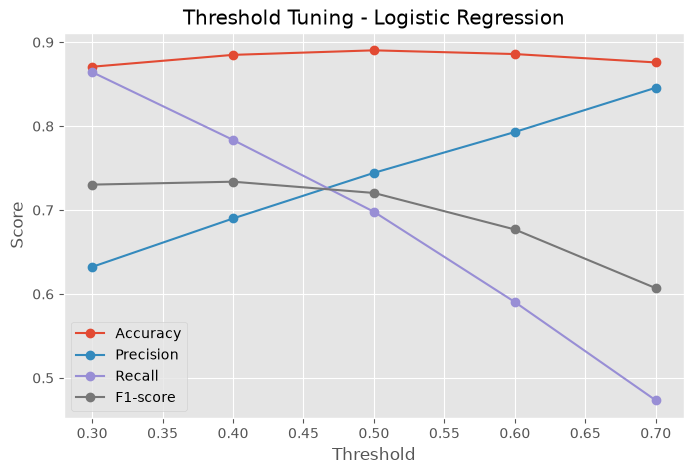

In [238]:
plt.figure(figsize=(8,5))

plt.plot(threshold_lr["Threshold"],threshold_lr["Accuracy"],marker='o',label="Accuracy")
plt.plot(threshold_lr["Threshold"],threshold_lr["Precision"],marker='o',label="Precision")
plt.plot(threshold_lr["Threshold"],threshold_lr["Recall"],marker='o',label="Recall")
plt.plot(threshold_lr["Threshold"],threshold_lr["F1-score"],marker='o',label="F1-score")

plt.title("Threshold Tuning - Logistic Regression")

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.legend()

plt.grid(True)

plt.show()

### Random Forest

In [239]:
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]

In [240]:
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

result_rf = []

for t in thresholds:

    pred = (y_prob_rf >= t).astype(int)

    report = classification_report(
        y_test,
        pred,
        output_dict=True
    )

    result_rf.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "F1-score": report['1']['f1-score']
    })

threshold_rf = pd.DataFrame(result_rf)

threshold_rf.round(3)

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.3,0.907,0.724,0.871,0.791
1,0.4,0.922,0.796,0.826,0.810
2,0.5,0.924,0.847,0.762,0.802
3,0.6,0.923,0.887,0.710,0.789
4,0.7,0.916,0.921,0.642,0.757


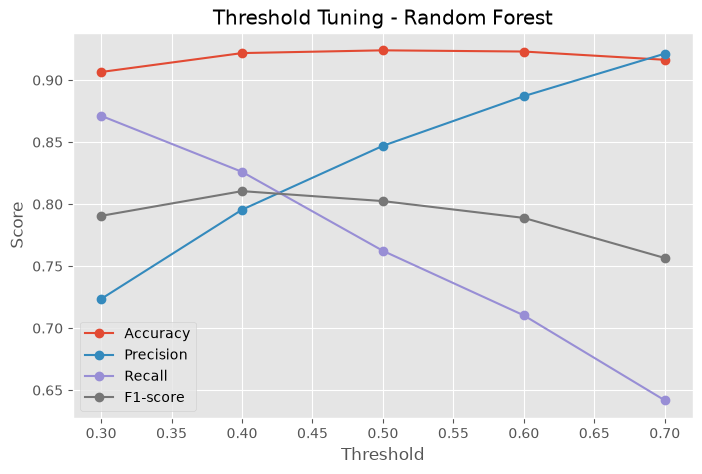

In [241]:
plt.figure(figsize=(8,5))

plt.plot(threshold_rf["Threshold"], threshold_rf["Accuracy"], marker='o', label="Accuracy")
plt.plot(threshold_rf["Threshold"], threshold_rf["Precision"], marker='o', label="Precision")
plt.plot(threshold_rf["Threshold"], threshold_rf["Recall"], marker='o', label="Recall")
plt.plot(threshold_rf["Threshold"], threshold_rf["F1-score"], marker='o', label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning - Random Forest")
plt.legend()
plt.grid(True)

plt.show()

### Interpretasi

Berdasarkan hasil Threshold Tuning, perubahan nilai threshold memberikan pengaruh terhadap keseimbangan antara accuracy, precision, recall, dan F1-score. Semakin tinggi nilai threshold, precision cenderung meningkat, sedangkan recall mengalami penurunan.

Pada penelitian ini, threshold **0,4** menghasilkan **F1-score tertinggi (0,810)** dengan accuracy sebesar **92,2%** dan recall sebesar **82,6%**, sehingga memberikan keseimbangan terbaik antara precision dan recall. Sementara itu, threshold **0,5** tetap memberikan accuracy tertinggi sebesar **92,4%**, namun dengan recall yang lebih rendah dibandingkan threshold 0,4.

### Support Vector Machine

Threshold Tuning pada Support Vector Machine dilakukan untuk mengetahui pengaruh perubahan nilai threshold terhadap accuracy, precision, recall, dan F1-score.

In [242]:
y_prob_svm = svm.predict_proba(X_test_scaled)[:,1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

result_svm = []

for t in thresholds:

    pred = (y_prob_svm >= t).astype(int)

    report = classification_report(
        y_test,
        pred,
        output_dict=True
    )

    result_svm.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": report['1']['precision'],
        "Recall": report['1']['recall'],
        "F1-score": report['1']['f1-score']
    })

threshold_svm = pd.DataFrame(result_svm)

threshold_svm.round(3)

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.3,0.876,0.645,0.855,0.736
1,0.4,0.888,0.698,0.782,0.738
2,0.5,0.893,0.750,0.704,0.727
3,0.6,0.888,0.793,0.602,0.685
4,0.7,0.877,0.840,0.485,0.615


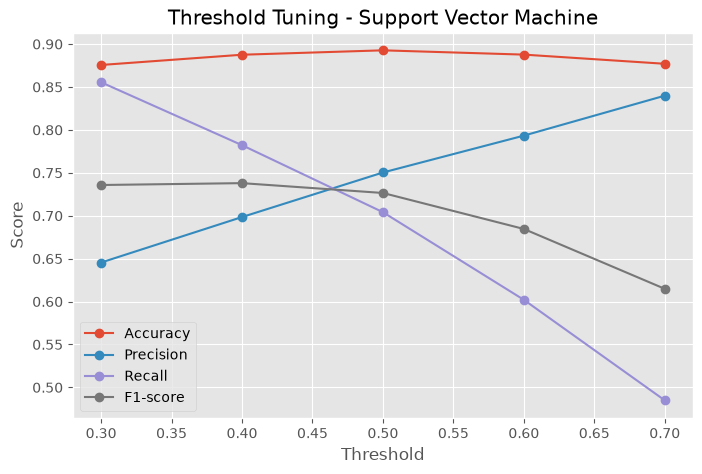

In [243]:
plt.figure(figsize=(8,5))

plt.plot(threshold_svm["Threshold"], threshold_svm["Accuracy"], marker='o', label="Accuracy")
plt.plot(threshold_svm["Threshold"], threshold_svm["Precision"], marker='o', label="Precision")
plt.plot(threshold_svm["Threshold"], threshold_svm["Recall"], marker='o', label="Recall")
plt.plot(threshold_svm["Threshold"], threshold_svm["F1-score"], marker='o', label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning - Support Vector Machine")
plt.legend()
plt.grid(True)

plt.show()

### Interpretasi

Perubahan nilai threshold pada Support Vector Machine memengaruhi keseimbangan antara accuracy, precision, recall, dan F1-score. Threshold yang menghasilkan nilai F1-score tertinggi dipilih sebagai threshold yang paling optimal karena memberikan keseimbangan terbaik antara precision dan recall.

### Perbandingan Threshold Terbaik

Berdasarkan hasil Threshold Tuning, dipilih threshold terbaik pada masing-masing algoritma berdasarkan nilai F1-score tertinggi. Pemilihan F1-score dilakukan karena metrik ini mampu memberikan keseimbangan antara precision dan recall, terutama pada dataset yang memiliki distribusi kelas tidak seimbang.

In [244]:
comparison_threshold = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Support Vector Machine'
    ],
    'Threshold Terbaik': [
        threshold_lr.loc[threshold_lr['Threshold'] == 0.4, 'Threshold'].values[0],
        threshold_rf.loc[threshold_rf['Threshold'] == 0.4, 'Threshold'].values[0],
        threshold_svm.loc[threshold_svm['Threshold'] == 0.4, 'Threshold'].values[0]
    ],
    'Accuracy': [
        threshold_lr.loc[threshold_lr['Threshold'] == 0.4, 'Accuracy'].values[0],
        threshold_rf.loc[threshold_rf['Threshold'] == 0.4, 'Accuracy'].values[0],
        threshold_svm.loc[threshold_svm['Threshold'] == 0.4, 'Accuracy'].values[0]
    ],
    'Precision': [
        threshold_lr.loc[threshold_lr['Threshold'] == 0.4, 'Precision'].values[0],
        threshold_rf.loc[threshold_rf['Threshold'] == 0.4, 'Precision'].values[0],
        threshold_svm.loc[threshold_svm['Threshold'] == 0.4, 'Precision'].values[0]
    ],
    'Recall': [
        threshold_lr.loc[threshold_lr['Threshold'] == 0.4, 'Recall'].values[0],
        threshold_rf.loc[threshold_rf['Threshold'] == 0.4, 'Recall'].values[0],
        threshold_svm.loc[threshold_svm['Threshold'] == 0.4, 'Recall'].values[0]
    ],
    'F1-score': [
        threshold_lr.loc[threshold_lr['Threshold'] == 0.4, 'F1-score'].values[0],
        threshold_rf.loc[threshold_rf['Threshold'] == 0.4, 'F1-score'].values[0],
        threshold_svm.loc[threshold_svm['Threshold'] == 0.4, 'F1-score'].values[0]
    ]
})

comparison_threshold.round(3)

,Model,Threshold Terbaik,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.4,0.885,0.690,0.784,0.734
1,Random Forest,0.4,0.922,0.796,0.826,0.810
2,Support Vector Machine,0.4,0.888,0.698,0.782,0.738


### Interpretasi

Hasil Threshold Tuning menunjukkan bahwa ketiga algoritma memperoleh performa terbaik pada **threshold 0,4** berdasarkan nilai F1-score. Dibandingkan threshold default sebesar 0,5, penggunaan threshold 0,4 mampu meningkatkan kemampuan model dalam mendeteksi kelas positif (recall) tanpa menurunkan accuracy secara signifikan.

Di antara ketiga algoritma, **Random Forest** tetap menjadi model dengan performa terbaik. Pada threshold 0,4, Random Forest memperoleh accuracy sebesar **92,2%**, precision **79,6%**, recall **82,6%**, dan F1-score **81,0%**. Hasil tersebut lebih baik dibandingkan Logistic Regression maupun Support Vector Machine, sehingga Random Forest dipilih sebagai model terbaik pada penelitian ini.

# BAB 7 HASIL DAN PEMBAHASAN

## 7.1 Interpretasi Model Terbaik

Berdasarkan seluruh proses pelatihan, evaluasi, dan improvement yang telah dilakukan, Random Forest dipilih sebagai model terbaik karena memperoleh performa paling tinggi dibandingkan Logistic Regression dan Support Vector Machine. Selain memiliki accuracy yang tinggi, Random Forest juga menunjukkan keseimbangan yang baik antara precision, recall, dan F1-score.

In [245]:
comparison_threshold.round(3)

,Model,Threshold Terbaik,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.4,0.885,0.690,0.784,0.734
1,Random Forest,0.4,0.922,0.796,0.826,0.810
2,Support Vector Machine,0.4,0.888,0.698,0.782,0.738


### Interpretasi

Berdasarkan hasil evaluasi setelah dilakukan berbagai teknik improvement, ketiga algoritma menunjukkan performa yang cukup baik dalam melakukan klasifikasi persetujuan pinjaman. Namun demikian, terdapat perbedaan pada nilai accuracy, precision, recall, dan F1-score yang dihasilkan oleh masing-masing algoritma.

Random Forest memperoleh performa terbaik dengan accuracy sebesar **92,2%**, precision **79,6%**, recall **82,6%**, dan F1-score **81,0%** pada threshold **0,4**. Nilai tersebut lebih tinggi dibandingkan Logistic Regression maupun Support Vector Machine, sehingga Random Forest dipilih sebagai model terbaik pada penelitian ini.



### Variabel Paling Berpengaruh

Untuk mengetahui fitur yang paling memengaruhi hasil prediksi, dilakukan analisis menggunakan **Feature Importance** pada model Random Forest. Semakin besar nilai importance, semakin besar pula pengaruh fitur tersebut terhadap keputusan model.

In [246]:
importance_top10 = importance.head(10).reset_index(drop=True)

importance_top10

,Feature,Importance
0,previous_loan_defaults_on_file_Yes,0.232794
1,loan_int_rate,0.217311
2,person_income,0.200282
3,loan_percent_income,0.170570
4,loan_amnt,0.090973
5,person_home_ownership_RENT,0.044721
6,loan_intent_EDUCATION,0.011324
7,person_home_ownership_OWN,0.010938
8,loan_intent_MEDICAL,0.010867
9,loan_intent_VENTURE,0.010220


### Visualisasi Feature Importance

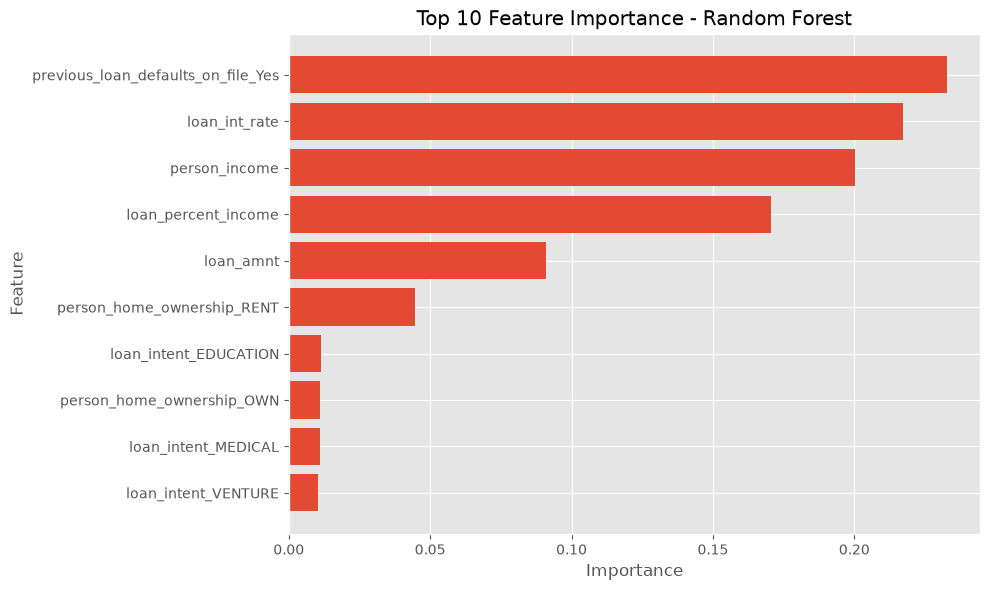

In [247]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_top10["Feature"][::-1],
    importance_top10["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Random Forest")

plt.tight_layout()

plt.show()

### Interpretasi

Tabel dan grafik di atas menunjukkan urutan fitur berdasarkan nilai Feature Importance pada model Random Forest.

Fitur **previous_loan_defaults_on_file_Yes** memiliki nilai importance paling tinggi, yaitu **0,232794**. ini menunjukkan bahwa riwayat gagal bayar sebelumnya menjadi faktor yang paling berpengaruh dalam menentukan apakah pengajuan pinjaman disetujui atau tidak.

Selanjutnya, fitur **loan_int_rate**, **person_income**, **loan_percent_income**, dan **loan_amnt** juga memiliki pengaruh yang besar. Hasil ini menunjukkan bahwa kondisi keuangan peminjam serta karakteristik pinjaman menjadi pertimbangan utama dalam proses prediksi.

Sementara itu, fitur seperti **person_home_ownership_RENT**, **loan_intent_EDUCATION**, **person_home_ownership_OWN**, **loan_intent_MEDICAL**, dan **loan_intent_VENTURE** memiliki nilai importance yang lebih rendah. Meskipun demikian, fitur-fitur tersebut tetap membantu model dalam meningkatkan akurasi prediksi.
|

### Implikasi Bisnis

Model Random Forest dapat digunakan sebagai alat bantu dalam proses persetujuan pinjaman. Dengan memanfaatkan hasil prediksi model, lembaga keuangan dapat melakukan proses penilaian calon peminjam secara lebih cepat dan konsisten.

Hasil penelitian, Random Forest memberikan performa yang paling baik dibandingkan algoritma lainnya. Hal ini menunjukkan bahwa model cukup andal untuk membantu mengidentifikasi calon peminjam yang berisiko maupun yang layak menerima pinjaman.

Selain menghasilkan prediksi, model juga menunjukkan bahwa riwayat gagal bayar, tingkat suku bunga, pendapatan, persentase pinjaman terhadap pendapatan, dan jumlah pinjaman merupakan faktor yang paling berpengaruh dalam proses penilaian. Informasi tersebut dapat membantu pihak lembaga keuangan dalam melakukan analisis kredit secara lebih objektif.


## 7.2 Kelebihan dan Kelemahan Model

#### Logistic Regression

**Kelebihan**
- Memiliki proses pelatihan yang relatif cepat.
- Model mudah dipahami dan diinterpretasikan.
- Cocok digunakan sebagai model dasar (baseline) untuk permasalahan klasifikasi biner.

**Kelemahan**
- Kurang mampu menangkap hubungan yang kompleks antar fitur.
- Performa yang diperoleh pada penelitian ini masih berada di bawah Random Forest, terutama pada nilai recall dan F1-score.


#### Random Forest

**Kelebihan**
- Memperoleh performa terbaik pada penelitian ini berdasarkan accuracy, precision, recall, dan F1-score.
- Mampu menangani hubungan yang kompleks antar fitur.
- Menyediakan informasi Feature Importance sehingga faktor yang memengaruhi prediksi dapat dianalisis.
- Tetap memberikan performa yang baik setelah dilakukan Hyperparameter Tuning dan Threshold Tuning.

**Kelemahan**
- Waktu pelatihan lebih lama dibandingkan Logistic Regression.
- Struktur model lebih kompleks sehingga hasil prediksi tidak semudah Logistic Regression untuk dijelaskan.
- Membutuhkan sumber daya komputasi yang lebih besar.

#### Support Vector Machine

**Kelebihan**
- Memiliki kemampuan klasifikasi yang baik pada data dengan batas keputusan yang kompleks.
- Menghasilkan performa yang cukup baik setelah dilakukan Hyperparameter Tuning.
- Mampu mempertahankan keseimbangan antara precision dan recall.

**Kelemahan**
- Membutuhkan proses pelatihan yang lebih lama dibandingkan Logistic Regression.
- Sensitif terhadap pemilihan parameter seperti nilai C dan kernel.
- Kurang memberikan interpretasi mengenai pengaruh setiap fitur karena tidak memiliki Feature Importance secara langsung.

Secara keseluruhan, ketiga algoritma memiliki karakteristik yang berbeda. Logistic Regression unggul dari sisi kesederhanaan dan kemudahan interpretasi, Support Vector Machine mampu memberikan performa yang cukup baik pada data klasifikasi, sedangkan Random Forest menghasilkan performa terbaik pada penelitian ini berdasarkan seluruh metrik evaluasi yang digunakan. Oleh karena itu, Random Forest dipilih sebagai model terbaik untuk kasus prediksi persetujuan pinjaman.

## 7.3 Kesimpulan dan Rekomendasi

### Kesimpulan

Penelitian ini berhasil membangun model machine learning untuk memprediksi persetujuan pinjaman menggunakan tiga algoritma klasifikasi, yaitu Logistic Regression, Random Forest, dan Support Vector Machine. Sebelum proses pemodelan dilakukan, data terlebih dahulu melalui tahap preprocessing yang meliputi penanganan missing value, pengecekan data duplikat, penanganan outlier, encoding, feature selection, standardisasi, serta pembagian data menjadi data latih dan data uji.

Hasil pengujian menunjukkan bahwa ketiga algoritma mampu melakukan klasifikasi dengan baik. Namun, Random Forest memberikan performa yang paling baik dibandingkan dua algoritma lainnya. Setelah dilakukan Hyperparameter Tuning, model ini memperoleh accuracy sebesar **92,53%**. Selain itu, Random Forest juga menghasilkan nilai precision, recall, dan F1-score yang lebih seimbang sehingga lebih andal dalam memprediksi persetujuan pinjaman.

Berdasarkan analisis Feature Importance, faktor yang paling berpengaruh dalam prediksi adalah **previous_loan_defaults_on_file**, **loan_int_rate**, **person_income**, **loan_percent_income**, dan **loan_amnt**. Dari seluruh proses pengujian dan improvement yang telah dilakukan, Random Forest dipilih sebagai model yang paling sesuai untuk digunakan pada kasus prediksi persetujuan pinjaman.

### Rekomendasi

Penelitian ini bisa dapat dikembangkan lebih lanjut. Salah satunya dengan menggunakan dataset yang lebih beragam atau menambahkan fitur lain yang berkaitan dengan riwayat kredit dan kondisi keuangan peminjam agar model dapat mempelajari pola yang lebih lengkap.

Selain itu, penelitian berikutnya dapat mencoba algoritma lain seperti XGBoost, LightGBM, atau CatBoost untuk melihat apakah performanya dapat melampaui Random Forest. Penggunaan metode Explainable AI (XAI) juga dapat menjadi pilihan agar alasan di balik setiap hasil prediksi dapat dijelaskan dengan lebih mudah kepada pengguna.